# Analysis: IQ-TREE GPU (OpenACC) vs CPU (VANILA) — Complex Models (Final)

**Date:** 2026-03-19
**Dataset:** 4 taxa, 10 nucleotide/amino acid sites
**Models tested:** LG, LG+G4, LG+I, LG+I+G4, LG+R4, LG+C60 (AA); GTR, GTR+G4, GTR+I, GTR+I+G4, GTR+R4 (DNA)
**Topologies:** rooted and unrooted
**Replicates:** 10 random trees per model

This analysis consolidates the final correct outputs across all bugfix iterations (base through bugfixes_v5).

In [1]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

cwd = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_19_complexdatafinal'
results_path = "/Users/u7826985/Projects/Nvidia/results/2026_03_19_complexdatafinal"
print(f"Working directory : {cwd}")
print(f"Results directory : {results_path}")
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 150, "font.size": 11})

Working directory : /Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_19_complexdatafinal
Results directory : /Users/u7826985/Projects/Nvidia/results/2026_03_19_complexdatafinal


# 1. Parse all .iqtree and .log files

In [2]:
# Patterns for .iqtree files
iqtree_ll_pattern = re.compile(r'Log-likelihood of the tree:\s+([-\d.]+)')
iqtree_rate_params = re.compile(r'Rate parameter R:')
iqtree_freerate_pattern = re.compile(r'Site proportion and rates:\s+(.+)')
iqtree_gamma_shape = re.compile(r'Gamma shape alpha:\s+([\d.]+)')
iqtree_pinvar = re.compile(r'Proportion of invariable sites:\s+([\d.]+)')

# Patterns for .log files
log_alignment_pattern = re.compile(r'Alignment has (\d+) sequences with (\d+) columns, (\d+) distinct patterns')
log_initial_ll = re.compile(r'Initial log-likelihood:\s+([-\d.]+)')
log_optimal_ll = re.compile(r'Optimal log-likelihood:\s+([-\d.]+)')
log_params_opt = re.compile(r'Parameters optimization took (\d+) rounds? \(([\d.]+) sec\)')
log_wallclock = re.compile(r'Total wall-clock time used:\s+([\d.]+)\s+sec')
log_underflow_deriv = re.compile(r'WARNING: Numerical underflow for OpenACC lh-derivative')
log_underflow_sites = re.compile(r'WARNING: Numerical underflow caused by alignment sites')
log_best_score = re.compile(r'BEST SCORE FOUND\s*:\s*([-\d.]+)')

In [3]:
def parse_iqtree_file(filepath):
    """Parse .iqtree file for final log-likelihood and model parameters."""
    with open(filepath, 'r') as f:
        content = f.read()
    
    result = {}
    
    # Final log-likelihood
    m = iqtree_ll_pattern.search(content)
    result['final_ll'] = float(m.group(1)) if m else np.nan
    
    # FreeRate site proportions and rates
    m = iqtree_freerate_pattern.search(content)
    if m:
        result['site_rates_str'] = m.group(1).strip()
        pairs = re.findall(r'\(([^)]+)\)', m.group(1))
        props = []
        rates = []
        has_nan = False
        for pair in pairs:
            parts = pair.split(',')
            if len(parts) == 2:
                try:
                    p, r = float(parts[0]), float(parts[1])
                    props.append(p)
                    rates.append(r)
                except ValueError:
                    has_nan = True
                    props.append(np.nan)
                    rates.append(np.nan)
        result['freerate_props'] = props
        result['freerate_rates'] = rates
        result['has_nan_rates'] = has_nan or any(np.isnan(r) for r in rates)
    else:
        result['site_rates_str'] = None
        result['freerate_props'] = []
        result['freerate_rates'] = []
        result['has_nan_rates'] = False
    
    # Gamma shape
    m = iqtree_gamma_shape.search(content)
    result['gamma_shape'] = float(m.group(1)) if m else np.nan
    
    # Proportion of invariable sites
    m = iqtree_pinvar.search(content)
    result['pinvar'] = float(m.group(1)) if m else np.nan
    
    return result


def parse_log_file(filepath):
    """Parse .log file for timing, likelihood progression, and warnings."""
    with open(filepath, 'r') as f:
        content = f.read()
    
    result = {}
    
    # Alignment info
    m = log_alignment_pattern.search(content)
    if m:
        result['taxa'] = int(m.group(1))
        result['sites'] = int(m.group(2))
        result['patterns'] = int(m.group(3))
    
    # Initial LL
    m = log_initial_ll.search(content)
    result['initial_ll'] = float(m.group(1)) if m else np.nan
    
    # Optimal LL
    m = log_optimal_ll.search(content)
    result['optimal_ll'] = float(m.group(1)) if m else np.nan
    
    # Best score
    m = log_best_score.search(content)
    result['best_score'] = float(m.group(1)) if m else np.nan
    
    # Parameters optimization
    m = log_params_opt.search(content)
    if m:
        result['opt_rounds'] = int(m.group(1))
        result['opt_time'] = float(m.group(2))
    else:
        result['opt_rounds'] = np.nan
        result['opt_time'] = np.nan
    
    # Wall-clock time
    m = log_wallclock.search(content)
    result['wallclock_time'] = float(m.group(1)) if m else np.nan
    
    # Underflow warnings
    result['n_underflow_deriv'] = len(log_underflow_deriv.findall(content))
    result['n_underflow_sites'] = len(log_underflow_sites.findall(content))
    result['has_underflow'] = result['n_underflow_deriv'] > 0 or result['n_underflow_sites'] > 0
    
    return result

In [4]:
def parse_all_results(results_path):
    """Parse all results from the directory structure."""
    rows = []
    
    for data_type in ['AA', 'DNA']:
        data_dir = os.path.join(results_path, data_type)
        if not os.path.exists(data_dir):
            continue
        
        for tree_type in ['rooted', 'unrooted']:
            tree_type_dir = os.path.join(data_dir, tree_type)
            if not os.path.exists(tree_type_dir):
                continue
            
            for model in sorted(os.listdir(tree_type_dir)):
                model_dir = os.path.join(tree_type_dir, model)
                if not os.path.isdir(model_dir):
                    continue
                
                for tree_folder in sorted(os.listdir(model_dir)):
                    tree_dir = os.path.join(model_dir, tree_folder)
                    if not os.path.isdir(tree_dir):
                        continue
                    
                    tree_num = int(re.search(r'(\d+)', tree_folder).group(1))
                    
                    files = os.listdir(tree_dir)
                    for backend_key, backend_name in [('VANILA', 'VANILA'), ('OPENACC', 'OPENACC')]:
                        log_files = [f for f in files if f.endswith('.log') and backend_key in f]
                        iqtree_files = [f for f in files if f.endswith('.iqtree') and backend_key in f]
                        
                        if not log_files or not iqtree_files:
                            continue
                        
                        log_path = os.path.join(tree_dir, log_files[0])
                        iqtree_path = os.path.join(tree_dir, iqtree_files[0])
                        
                        log_data = parse_log_file(log_path)
                        iqtree_data = parse_iqtree_file(iqtree_path)
                        
                        row = {
                            'data_type': data_type,
                            'tree_type': tree_type,
                            'model': model,
                            'tree_num': tree_num,
                            'tree_folder': tree_folder,
                            'backend': backend_name,
                            **log_data,
                            **iqtree_data,
                        }
                        rows.append(row)
    
    df = pd.DataFrame(rows)
    return df

df = parse_all_results(results_path)
print(f"Total records parsed: {len(df)}")
print(f"\nRecords per data_type x tree_type x model x backend:")
summary = df.groupby(['data_type', 'tree_type', 'model', 'backend']).size().unstack(fill_value=0)
display(summary)

Total records parsed: 400

Records per data_type x tree_type x model x backend:


backend                       OPENACC  VANILA
data_type tree_type model                    
AA        rooted    LG             10      10
                    LG+G4          10      10
                    LG+I           10      10
                    LG+I+G4        10      10
                    LG+R4          10      10
          unrooted  LG             10      10
                    LG+G4          10      10
                    LG+I           10      10
                    LG+I+G4        10      10
                    LG+R4          10      10
DNA       rooted    GTR            10      10
                    GTR+G4         10      10
                    GTR+I          10      10
                    GTR+I+G4       10      10
                    GTR+R4         10      10
          unrooted  GTR            10      10
                    GTR+G4         10      10
                    GTR+I          10      10
                    GTR+I+G4       10      10
                    GTR+R4         10      10

# 2. Numerical Correctness: Log-Likelihood Comparison (OpenACC vs VANILA)

In [5]:
# Pivot: for each (data_type, tree_type, model, tree_num), compare VANILA vs OPENACC final_ll
merge_keys = ['data_type', 'tree_type', 'model', 'tree_num']

vanila = df[df['backend'] == 'VANILA'][merge_keys + ['final_ll', 'optimal_ll', 'best_score', 'opt_rounds', 'opt_time', 'wallclock_time']].copy()
openacc = df[df['backend'] == 'OPENACC'][merge_keys + ['final_ll', 'optimal_ll', 'best_score', 'opt_rounds', 'opt_time', 'wallclock_time', 
             'has_underflow', 'n_underflow_deriv', 'n_underflow_sites', 'has_nan_rates']].copy()

vanila = vanila.rename(columns={c: f'{c}_vanila' for c in vanila.columns if c not in merge_keys})
openacc = openacc.rename(columns={c: f'{c}_openacc' for c in openacc.columns if c not in merge_keys})

merged = vanila.merge(openacc, on=merge_keys, how='outer', indicator=True)

print("Merge status:")
print(merged['_merge'].value_counts())
print(f"\nTotal matched pairs (both backends): {(merged['_merge'] == 'both').sum()}")
print(f"VANILA only: {(merged['_merge'] == 'left_only').sum()}")
print(f"OPENACC only: {(merged['_merge'] == 'right_only').sum()}")

Merge status:
_merge
both          200
left_only       0
right_only      0
Name: count, dtype: int64

Total matched pairs (both backends): 200
VANILA only: 0
OPENACC only: 0


In [6]:
# Compute LL differences for matched pairs
both = merged[merged['_merge'] == 'both'].copy()
both['ll_diff'] = both['final_ll_openacc'] - both['final_ll_vanila']
both['ll_abs_diff'] = both['ll_diff'].abs()
both['ll_match'] = both['ll_abs_diff'] < 0.01  # within 0.01 logL units

print("=" * 90)
print("LOG-LIKELIHOOD DIFFERENCE: OpenACC vs VANILA (final_ll from .iqtree)")
print("=" * 90)

ll_summary = both.groupby(['data_type', 'tree_type', 'model']).agg(
    n_pairs=('ll_diff', 'count'),
    mean_diff=('ll_diff', 'mean'),
    max_abs_diff=('ll_abs_diff', 'max'),
    min_diff=('ll_diff', 'min'),
    max_diff=('ll_diff', 'max'),
    n_match=('ll_match', 'sum'),
    pct_match=('ll_match', 'mean'),
    n_underflow=('has_underflow_openacc', 'sum'),
    n_nan_rates=('has_nan_rates_openacc', 'sum'),
).round(6)
ll_summary['pct_match'] = (ll_summary['pct_match'] * 100).round(1)

display(ll_summary)

LOG-LIKELIHOOD DIFFERENCE: OpenACC vs VANILA (final_ll from .iqtree)


n_pairs  mean_diff  max_abs_diff  min_diff  \
data_type tree_type model                                                  
AA        rooted    LG             10    0.00000        0.0000    0.0000   
                    LG+G4          10    0.00000        0.0000    0.0000   
                    LG+I           10    0.00000        0.0000    0.0000   
                    LG+I+G4        10    0.00000        0.0000    0.0000   
                    LG+R4          10    0.00000        0.0000    0.0000   
          unrooted  LG             10    0.00000        0.0000    0.0000   
                    LG+G4          10    0.00000        0.0000    0.0000   
                    LG+I           10    0.00000        0.0000    0.0000   
                    LG+I+G4        10    0.00000        0.0000    0.0000   
                    LG+R4          10   -0.00001        0.0001   -0.0001   
DNA       rooted    GTR            10    0.00007        0.0012   -0.0003   
                    GTR+G4         10    0.00000        0.0001   -0.0001   
                    GTR+I          10   -0.00035        0.0028   -0.0028   
                    GTR+I+G4       10    0.00445        0.0405    0.0000   
                    GTR+R4         10    0.00118        0.0121   -0.0011   
          unrooted  GTR            10    0.00036        0.0039   -0.0006   
                    GTR+G4         10    0.00001        0.0001    0.0000   
                    GTR+I          10    0.00000        0.0000    0.0000   
                    GTR+I+G4       10   -0.00020        0.0015   -0.0015   
                    GTR+R4         10   -0.00004        0.0031   -0.0018   

                              max_diff  n_match  pct_match  n_underflow  \
data_type tree_type model                                                 
AA        rooted    LG          0.0000       10      100.0            0   
                    LG+G4       0.0000       10      100.0            0   
                    LG+I        0.0000       10      100.0            0   
                    LG+I+G4     0.0000       10      100.0            0   
                    LG+R4       0.0000       10      100.0            0   
          unrooted  LG          0.0000       10      100.0            0   
                    LG+G4       0.0000       10      100.0            0   
                    LG+I        0.0000       10      100.0            0   
                    LG+I+G4     0.0000       10      100.0            0   
                    LG+R4       0.0000       10      100.0            0   
DNA       rooted    GTR         0.0012       10      100.0            0   
                    GTR+G4      0.0001       10      100.0            0   
                    GTR+I       0.0003       10      100.0            0   
                    GTR+I+G4    0.0405        9       90.0            0   
                    GTR+R4      0.0121        9       90.0            0   
          unrooted  GTR         0.0039       10      100.0            0   
                    GTR+G4      0.0001       10      100.0            0   
                    GTR+I       0.0000       10      100.0            0   
                    GTR+I+G4    0.0001       10      100.0            0   
                    GTR+R4      0.0031       10      100.0            0   

                              n_nan_rates  
data_type tree_type model                  
AA        rooted    LG                  0  
                    LG+G4               0  
                    LG+I                0  
                    LG+I+G4             0  
                    LG+R4               0  
          unrooted  LG                  0  
                    LG+G4               0  
                    LG+I                0  
                    LG+I+G4             0  
                    LG+R4               0  
DNA       rooted    GTR                 0  
                    GTR+G4              0  
                    GTR+I               0  
                    GTR+I+G4            0  
  

In [7]:
# Detailed view: separate CORRECT models vs BROKEN models
print("\n" + "=" * 90)
print("CORRECT MODELS (all trees match within 0.01 logL, no underflow)")
print("=" * 90)
correct_models = ll_summary[(ll_summary['max_abs_diff'] < 0.01) & (ll_summary['n_underflow'] == 0)]
display(correct_models[['n_pairs', 'mean_diff', 'max_abs_diff']])

print("\n" + "=" * 90)
print("MODELS WITH ISSUES (LL mismatch > 0.01 OR underflow warnings)")
print("=" * 90)
problem_models = ll_summary[(ll_summary['max_abs_diff'] >= 0.01) | (ll_summary['n_underflow'] > 0)]
display(problem_models)


CORRECT MODELS (all trees match within 0.01 logL, no underflow)


n_pairs  mean_diff  max_abs_diff
data_type tree_type model                                     
AA        rooted    LG             10    0.00000        0.0000
                    LG+G4          10    0.00000        0.0000
                    LG+I           10    0.00000        0.0000
                    LG+I+G4        10    0.00000        0.0000
                    LG+R4          10    0.00000        0.0000
          unrooted  LG             10    0.00000        0.0000
                    LG+G4          10    0.00000        0.0000
                    LG+I           10    0.00000        0.0000
                    LG+I+G4        10    0.00000        0.0000
                    LG+R4          10   -0.00001        0.0001
DNA       rooted    GTR            10    0.00007        0.0012
                    GTR+G4         10    0.00000        0.0001
                    GTR+I          10   -0.00035        0.0028
          unrooted  GTR            10    0.00036        0.0039
                    GTR+G4         10    0.00001        0.0001
                    GTR+I          10    0.00000        0.0000
                    GTR+I+G4       10   -0.00020        0.0015
                    GTR+R4         10   -0.00004        0.0031


MODELS WITH ISSUES (LL mismatch > 0.01 OR underflow warnings)


n_pairs  mean_diff  max_abs_diff  min_diff  \
data_type tree_type model                                                  
DNA       rooted    GTR+I+G4       10    0.00445        0.0405    0.0000   
                    GTR+R4         10    0.00118        0.0121   -0.0011   

                              max_diff  n_match  pct_match  n_underflow  \
data_type tree_type model                                                 
DNA       rooted    GTR+I+G4    0.0405        9       90.0            0   
                    GTR+R4      0.0121        9       90.0            0   

                              n_nan_rates  
data_type tree_type model                  
DNA       rooted    GTR+I+G4            0  
                    GTR+R4              0

# 3. Underflow Analysis

In [8]:
# Which models/backends have underflow?
underflow_df = df[df['has_underflow'] == True].copy()

print(f"Total runs with underflow warnings: {len(underflow_df)}")
print(f"\nBreakdown by backend:")
print(underflow_df['backend'].value_counts())

print(f"\nBreakdown by model:")
uf_summary = underflow_df.groupby(['data_type', 'tree_type', 'model', 'backend']).agg(
    n_runs=('has_underflow', 'count'),
    mean_deriv_warnings=('n_underflow_deriv', 'mean'),
    max_deriv_warnings=('n_underflow_deriv', 'max'),
    n_site_warnings=('n_underflow_sites', 'sum'),
    n_nan_rates=('has_nan_rates', 'sum'),
).round(1)
display(uf_summary)

Total runs with underflow warnings: 0

Breakdown by backend:
Series([], Name: count, dtype: int64)

Breakdown by model:


,,,,n_runs,mean_deriv_warnings,max_deriv_warnings,n_site_warnings,n_nan_rates
data_type,tree_type,model,backend,,,,,


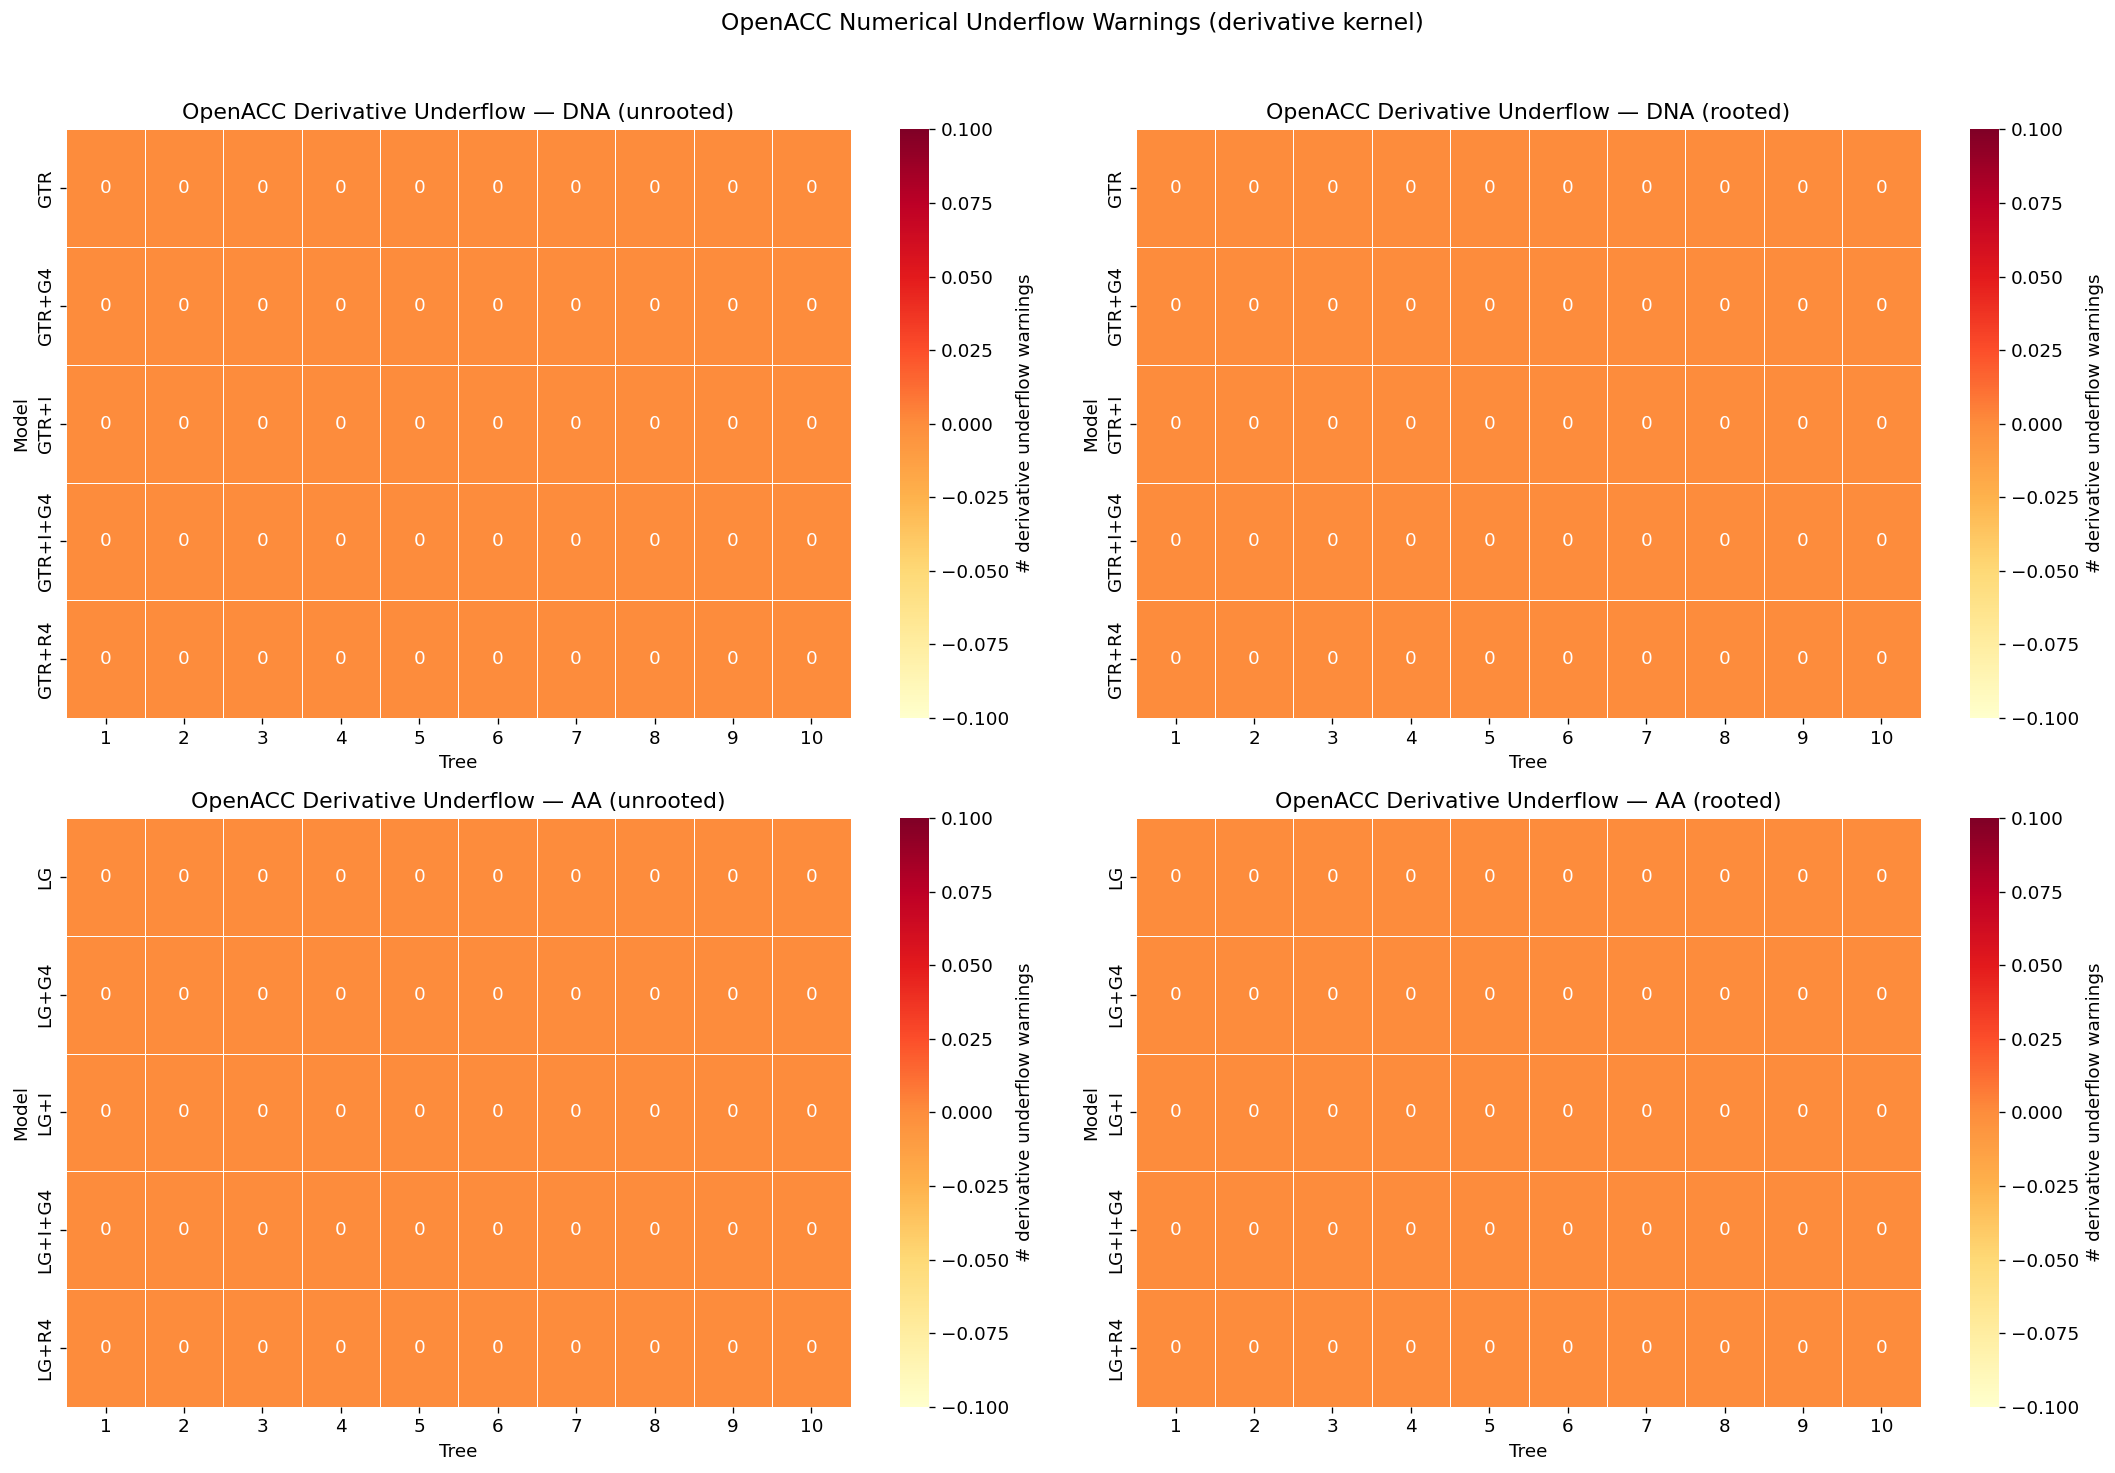

In [9]:
# Heatmap: underflow warning count per model per tree
openacc_df = df[df['backend'] == 'OPENACC'].copy()

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
combos = [
    ('DNA', 'unrooted', axes[0, 0]),
    ('DNA', 'rooted',   axes[0, 1]),
    ('AA',  'unrooted', axes[1, 0]),
    ('AA',  'rooted',   axes[1, 1]),
]

for data_type, tree_type, ax in combos:
    subset = openacc_df[(openacc_df['data_type'] == data_type) & 
                        (openacc_df['tree_type'] == tree_type)]
    if len(subset) == 0:
        ax.set_title(f'{data_type} ({tree_type}) \u2014 No data')
        ax.axis('off')
        continue
    
    pivot = subset.pivot_table(index='model', columns='tree_num', 
                                values='n_underflow_deriv', aggfunc='sum', fill_value=0)
    pivot = pivot[sorted(pivot.columns)].astype(int)
    
    sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5,
                cbar_kws={'label': '# derivative underflow warnings'})
    ax.set_title(f'OpenACC Derivative Underflow \u2014 {data_type} ({tree_type})')
    ax.set_xlabel('Tree')
    ax.set_ylabel('Model')

plt.suptitle('OpenACC Numerical Underflow Warnings (derivative kernel)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{cwd}/underflow_heatmap.png', bbox_inches='tight')
plt.show()

# 4. Log-Likelihood Difference Heatmaps

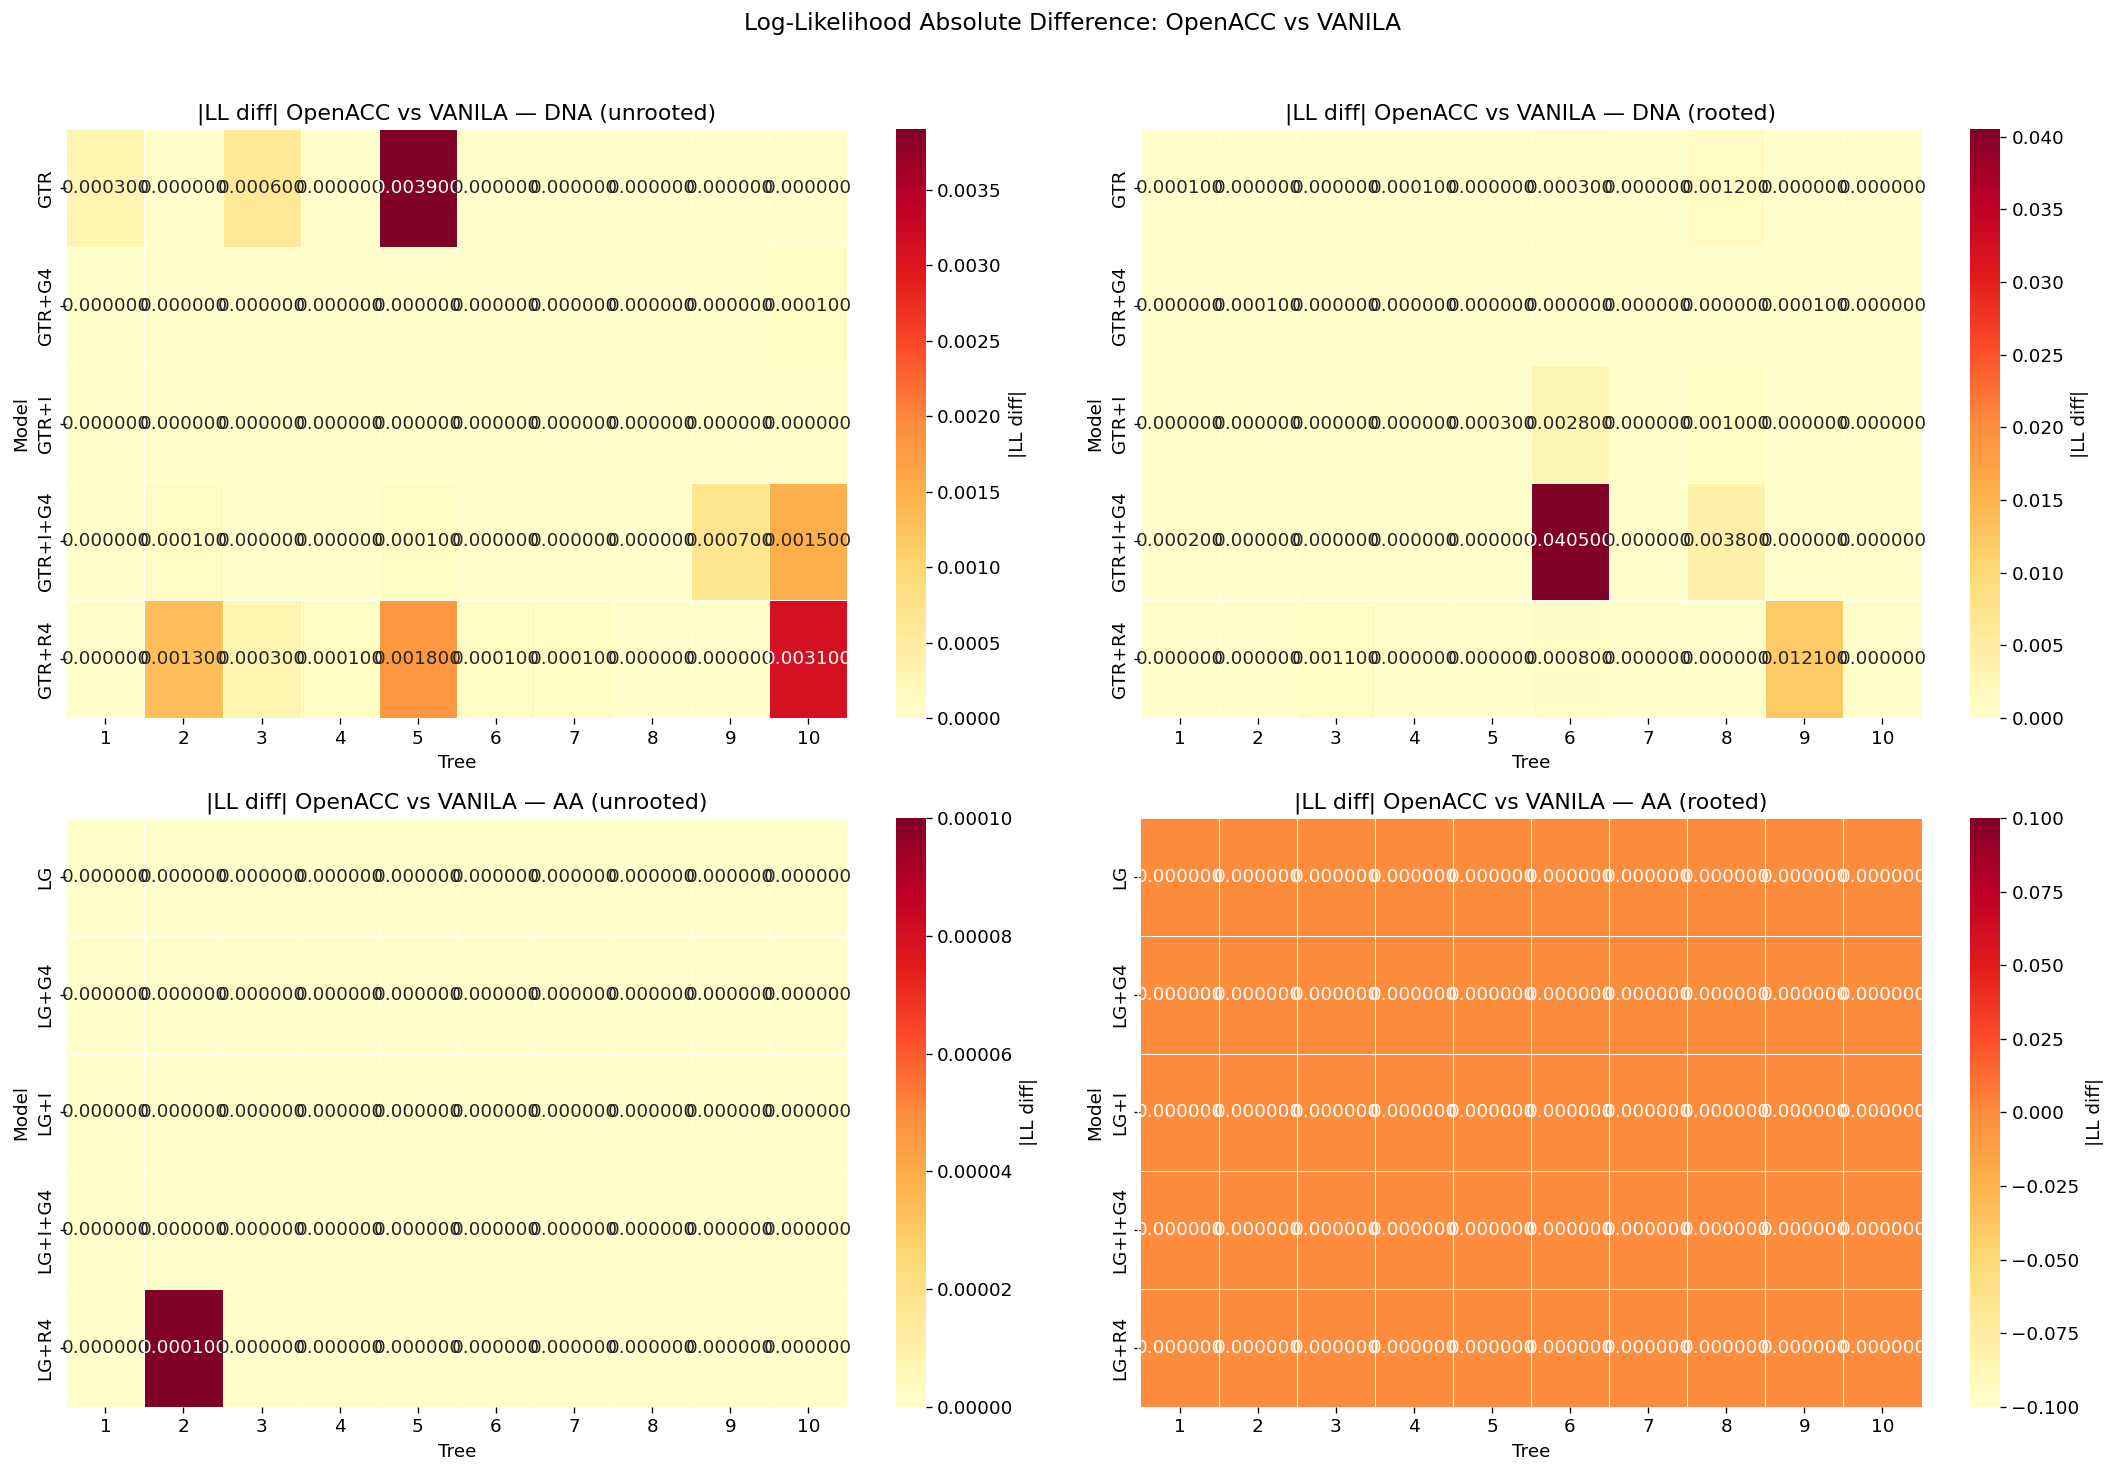

In [10]:
# LL difference heatmap per (model, tree_num)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
combos = [
    ('DNA', 'unrooted', axes[0, 0]),
    ('DNA', 'rooted',   axes[0, 1]),
    ('AA',  'unrooted', axes[1, 0]),
    ('AA',  'rooted',   axes[1, 1]),
]

for data_type, tree_type, ax in combos:
    subset = both[(both['data_type'] == data_type) & (both['tree_type'] == tree_type)]
    if len(subset) == 0:
        ax.set_title(f'{data_type} ({tree_type}) \u2014 No data')
        ax.axis('off')
        continue
    
    pivot = subset.pivot_table(index='model', columns='tree_num', 
                                values='ll_abs_diff', aggfunc='max', fill_value=0)
    pivot = pivot[sorted(pivot.columns)]
    
    max_val = pivot.max().max()
    if max_val > 1.0:
        from matplotlib.colors import LogNorm
        pivot_plot = pivot.replace(0, 1e-10)
        sns.heatmap(pivot_plot, annot=pivot.round(4).values, fmt='', cmap='YlOrRd', ax=ax,
                    linewidths=0.5, norm=LogNorm(vmin=1e-6, vmax=max_val),
                    cbar_kws={'label': '|LL diff| (log scale)'})
    else:
        sns.heatmap(pivot, annot=True, fmt='.6f', cmap='YlOrRd', ax=ax, linewidths=0.5,
                    cbar_kws={'label': '|LL diff|'})
    
    ax.set_title(f'|LL diff| OpenACC vs VANILA \u2014 {data_type} ({tree_type})')
    ax.set_xlabel('Tree')
    ax.set_ylabel('Model')

plt.suptitle('Log-Likelihood Absolute Difference: OpenACC vs VANILA', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{cwd}/ll_diff_heatmap.png', bbox_inches='tight')
plt.show()

# 5. Detailed Comparison for Each Model

In [11]:
# Per-model comparison table
for (dt, tt), group in both.groupby(['data_type', 'tree_type']):
    print(f"\n{'='*80}")
    print(f"{dt} \u2014 {tt}")
    print(f"{'='*80}")
    for model in sorted(group['model'].unique()):
        mg = group[group['model'] == model]
        n_match = (mg['ll_abs_diff'] < 0.01).sum()
        n_total = len(mg)
        max_diff = mg['ll_abs_diff'].max()
        status = '\u2705 PASS' if n_match == n_total else '\u274c FAIL'
        print(f"  {model:15s}: {n_match}/{n_total} exact, max|diff|={max_diff:.6f}  {status}")


AA — rooted
  LG             : 10/10 exact, max|diff|=0.000000  ✅ PASS
  LG+G4          : 10/10 exact, max|diff|=0.000000  ✅ PASS
  LG+I           : 10/10 exact, max|diff|=0.000000  ✅ PASS
  LG+I+G4        : 10/10 exact, max|diff|=0.000000  ✅ PASS
  LG+R4          : 10/10 exact, max|diff|=0.000000  ✅ PASS

AA — unrooted
  LG             : 10/10 exact, max|diff|=0.000000  ✅ PASS
  LG+G4          : 10/10 exact, max|diff|=0.000000  ✅ PASS
  LG+I           : 10/10 exact, max|diff|=0.000000  ✅ PASS
  LG+I+G4        : 10/10 exact, max|diff|=0.000000  ✅ PASS
  LG+R4          : 10/10 exact, max|diff|=0.000100  ✅ PASS

DNA — rooted
  GTR            : 10/10 exact, max|diff|=0.001200  ✅ PASS
  GTR+G4         : 10/10 exact, max|diff|=0.000100  ✅ PASS
  GTR+I          : 10/10 exact, max|diff|=0.002800  ✅ PASS
  GTR+I+G4       : 9/10 exact, max|diff|=0.040500  ❌ FAIL
  GTR+R4         : 9/10 exact, max|diff|=0.012100  ❌ FAIL

DNA — unrooted
  GTR            : 10/10 exact, max|diff|=0.003900  ✅ PASS


# 6. FreeRate (+R4) Parameters Comparison

In [12]:
# Compare FreeRate parameters between VANILA and OPENACC
r4_models = df[df['model'].str.contains('R4')].copy()

if len(r4_models) > 0:
    print("=" * 90)
    print("FREERATE (+R4) PARAMETER COMPARISON")
    print("=" * 90)
    
    for (dt, tt, model, tree_num), group in r4_models.groupby(['data_type', 'tree_type', 'model', 'tree_num']):
        print(f"\n--- {dt}/{tt}/{model}/tree_{tree_num} ---")
        for _, row in group.iterrows():
            backend = row['backend']
            ll = row['final_ll']
            rates_str = row.get('site_rates_str', 'N/A')
            has_nan = row.get('has_nan_rates', False)
            n_uf = row.get('n_underflow_deriv', 0)
            print(f"  {backend:10s}: LL={ll:15.4f}  rates={rates_str}")
            if has_nan:
                print(f"              *** HAS NaN RATES ***")
            if n_uf > 0:
                print(f"              *** {n_uf} derivative underflow warnings ***")
else:
    print("No +R4 models found.")

FREERATE (+R4) PARAMETER COMPARISON

--- AA/rooted/LG+R4/tree_1 ---
  VANILA    : LL=       -60.6027  rates=(0.2182,0.2208) (0.2471,0.7465) (0.2733,1.2704) (0.2614,1.6075)
  OPENACC   : LL=       -60.6027  rates=(0.2182,0.2208) (0.2471,0.7465) (0.2733,1.2704) (0.2614,1.6075)

--- AA/rooted/LG+R4/tree_2 ---
  VANILA    : LL=       -48.1782  rates=(0.2031,0.9246) (0.2575,1.0030) (0.2791,1.0222) (0.2603,1.0320)
  OPENACC   : LL=       -48.1782  rates=(0.2031,0.9248) (0.2575,1.0030) (0.2791,1.0220) (0.2603,1.0321)

--- AA/rooted/LG+R4/tree_3 ---
  VANILA    : LL=       -55.1647  rates=(0.2233,0.1628) (0.2399,0.8008) (0.2736,1.3218) (0.2632,1.5574)
  OPENACC   : LL=       -55.1647  rates=(0.2233,0.1628) (0.2399,0.8008) (0.2736,1.3218) (0.2632,1.5574)

--- AA/rooted/LG+R4/tree_4 ---
  VANILA    : LL=       -50.9005  rates=(0.2072,0.3506) (0.2515,0.9829) (0.2762,1.2171) (0.2651,1.2976)
  OPENACC   : LL=       -50.9005  rates=(0.2072,0.3506) (0.2515,0.9829) (0.2762,1.2171) (0.2651,1.2976)

---

# 7. Timing Comparison

In [13]:
# Opt time and wallclock comparison
print("=" * 90)
print("TIMING SUMMARY (seconds)")
print("=" * 90)

timing = df.groupby(['data_type', 'tree_type', 'model', 'backend']).agg(
    mean_opt=('opt_time', 'mean'),
    mean_wc=('wallclock_time', 'mean'),
    mean_rounds=('opt_rounds', 'mean'),
).round(4)
display(timing)

TIMING SUMMARY (seconds)


mean_opt  mean_wc  mean_rounds
data_type tree_type model    backend                                
AA        rooted    LG       OPENACC    0.0143   0.0356          1.0
                             VANILA     0.0000   0.0110          1.0
                    LG+G4    OPENACC    0.0457   0.0783          2.5
                             VANILA     0.0031   0.0111          2.5
                    LG+I     OPENACC    0.0256   0.0369          2.5
                             VANILA     0.0021   0.0320          2.5
                    LG+I+G4  OPENACC       NaN   0.6433          NaN
                             VANILA        NaN   0.0597          NaN
                    LG+R4    OPENACC    0.1265   0.1381          3.1
                             VANILA     0.0127   0.0232          3.1
          unrooted  LG       OPENACC    0.0146   0.0411          1.0
                             VANILA     0.0000   0.0113          1.0
                    LG+G4    OPENACC    0.0438   0.0679          2.6
                             VANILA     0.0029   0.0112          2.6
                    LG+I     OPENACC    0.0220   0.0422          2.1
                             VANILA     0.0015   0.0134          2.1
                    LG+I+G4  OPENACC       NaN   0.4863          NaN
                             VANILA        NaN   0.0652          NaN
                    LG+R4    OPENACC    0.1742   0.1825          4.4
                             VANILA     0.0176   0.0305          4.4
DNA       rooted    GTR      OPENACC    0.0529   0.0621          5.0
                             VANILA     0.0032   0.0380          5.0
                    GTR+G4   OPENACC    0.0762   0.0856          6.3
                             VANILA     0.0042   0.0192          6.3
                    GTR+I    OPENACC    0.1124   0.1223          8.5
                             VANILA     0.0047   0.0257          8.5
                    GTR+I+G4 OPENACC       NaN   0.6914          NaN
                             VANILA        NaN   0.0522          NaN
                    GTR+R4   OPENACC    0.1867   0.2221          5.5
                             VANILA     0.0071   0.0173          5.4
          unrooted  GTR      OPENACC    0.0524   0.1501          5.1
                             VANILA     0.0017   0.0112          5.1
                    GTR+G4   OPENACC    0.0648   0.0993          4.5
                             VANILA     0.0037   0.0348          4.5
                    GTR+I    OPENACC    0.0794   0.1407          4.7
                             VANILA     0.0024   0.0121          4.7
                    GTR+I+G4 OPENACC       NaN   0.8677          NaN
                             VANILA        NaN   0.0406          NaN
                    GTR+R4   OPENACC    0.2015   0.2101          6.0
                             VANILA     0.0083   0.0398          5.9

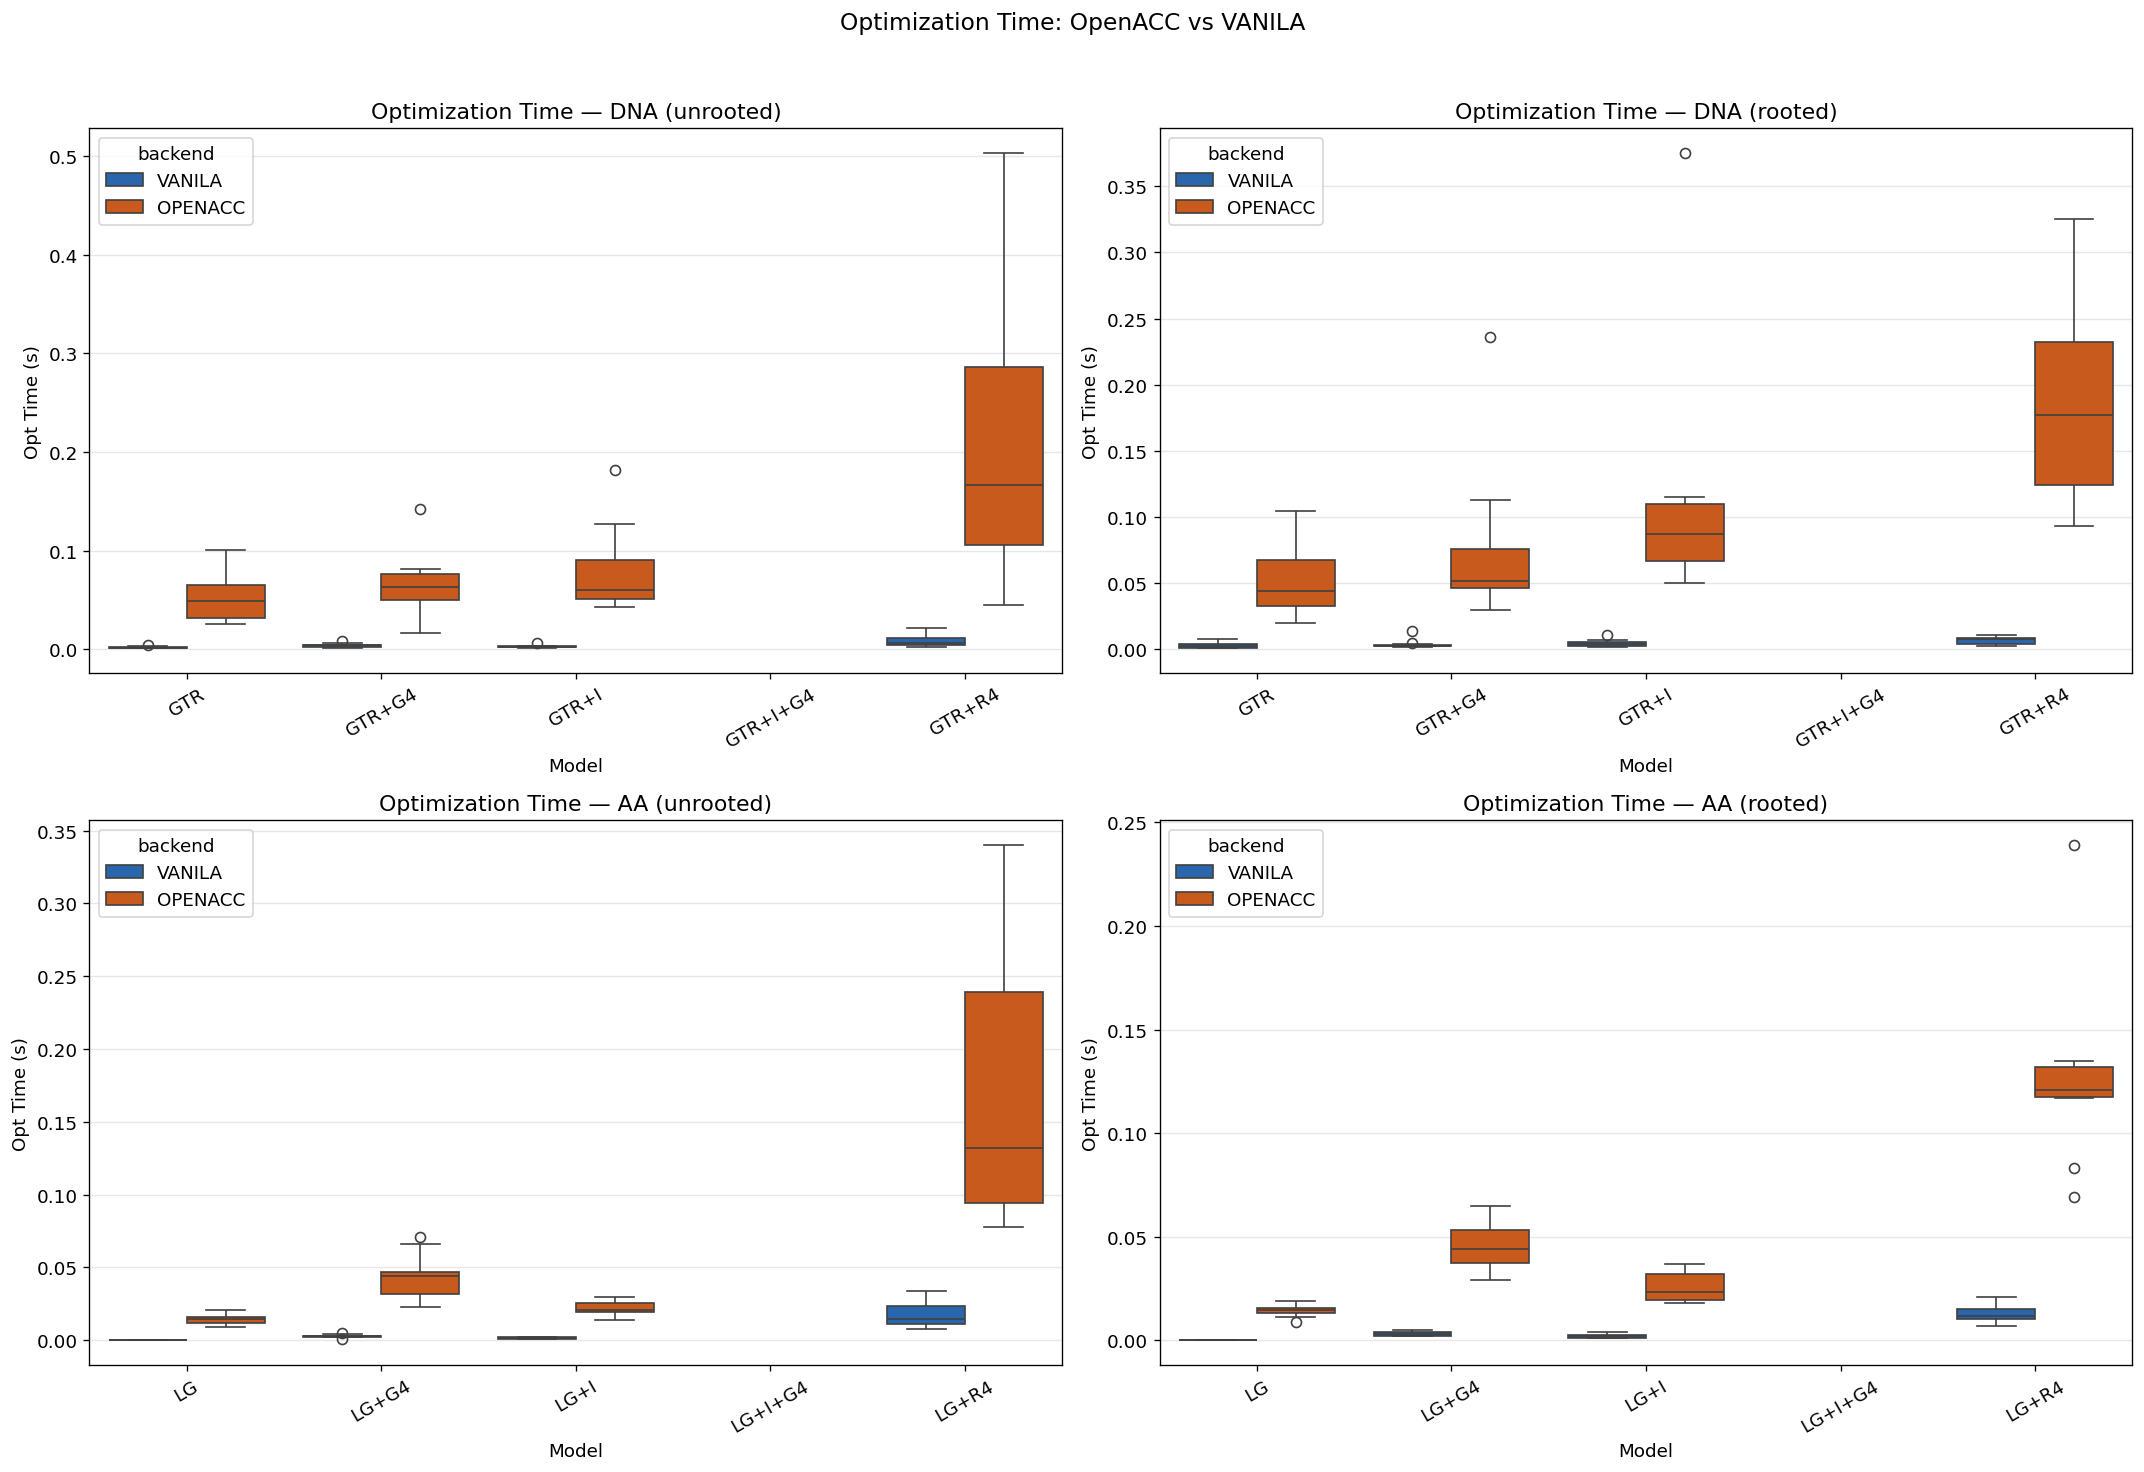

In [14]:
# Boxplot: optimization time by model, colored by backend
BACKEND_PALETTE = {'VANILA': '#1565C0', 'OPENACC': '#E65100'}
BACKEND_ORDER = ['VANILA', 'OPENACC']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
combos = [
    ('DNA', 'unrooted', axes[0, 0]),
    ('DNA', 'rooted',   axes[0, 1]),
    ('AA',  'unrooted', axes[1, 0]),
    ('AA',  'rooted',   axes[1, 1]),
]

for data_type, tree_type, ax in combos:
    subset = df[(df['data_type'] == data_type) & (df['tree_type'] == tree_type)]
    if len(subset) == 0:
        ax.set_title(f'{data_type} ({tree_type}) \u2014 No data')
        ax.axis('off')
        continue
    
    present = [b for b in BACKEND_ORDER if b in subset['backend'].unique()]
    model_order = sorted(subset['model'].unique())
    
    sns.boxplot(data=subset, x='model', y='opt_time', hue='backend',
                hue_order=present, palette=BACKEND_PALETTE, ax=ax, order=model_order)
    ax.set_title(f'Optimization Time \u2014 {data_type} ({tree_type})')
    ax.set_xlabel('Model')
    ax.set_ylabel('Opt Time (s)')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Optimization Time: OpenACC vs VANILA', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{cwd}/opt_time_comparison.png', bbox_inches='tight')
plt.show()

# 8. Model Correctness Summary

In [15]:
# Final correctness matrix: per model, 3-tier status (PASS / CLOSE / FAIL)
print("=" * 90)
print("MODEL CORRECTNESS MATRIX \u2014 OpenACC vs VANILA")
print("=" * 90)
print("Criteria:")
print("  PASS  : max|LL diff| < 0.01 across all trees (exact match)")
print("  CLOSE : max|LL diff| < 1.0 across all trees (closely equal)")
print("  FAIL  : max|LL diff| \u2265 1.0 (significantly different)")
print()

correctness_rows = []

for (dt, tt, model), group in both.groupby(['data_type', 'tree_type', 'model']):
    n_total = len(group)
    n_ll_match = (group['ll_abs_diff'] < 0.01).sum()
    n_ll_close = (group['ll_abs_diff'] < 1.0).sum()
    n_no_underflow = (~group['has_underflow_openacc']).sum()
    n_no_nan = (~group['has_nan_rates_openacc']).sum()
    max_diff = group['ll_abs_diff'].max()
    mean_diff = group['ll_diff'].mean()
    
    if (n_ll_match == n_total) and (n_no_underflow == n_total) and (n_no_nan == n_total):
        status = '\u2705 PASS'
    elif (n_ll_close == n_total) and (n_no_underflow == n_total) and (n_no_nan == n_total):
        status = '\u2248 CLOSE'
    else:
        status = '\u274c FAIL'
    
    correctness_rows.append({
        'data_type': dt,
        'tree_type': tt,
        'model': model,
        'n_trees': n_total,
        'n_ll_exact (<0.01)': n_ll_match,
        'n_ll_close (<1.0)': n_ll_close,
        'max |LL diff|': round(max_diff, 6),
        'mean LL diff': round(mean_diff, 6),
        'n_no_underflow': n_no_underflow,
        'n_no_nan_rates': n_no_nan,
        'STATUS': status,
    })

correctness_df = pd.DataFrame(correctness_rows)
display(correctness_df.set_index(['data_type', 'tree_type', 'model']))

MODEL CORRECTNESS MATRIX — OpenACC vs VANILA
Criteria:
  PASS  : max|LL diff| < 0.01 across all trees (exact match)
  CLOSE : max|LL diff| < 1.0 across all trees (closely equal)
  FAIL  : max|LL diff| ≥ 1.0 (significantly different)



n_trees  n_ll_exact (<0.01)  n_ll_close (<1.0)  \
data_type tree_type model                                                      
AA        rooted    LG             10                  10                 10   
                    LG+G4          10                  10                 10   
                    LG+I           10                  10                 10   
                    LG+I+G4        10                  10                 10   
                    LG+R4          10                  10                 10   
          unrooted  LG             10                  10                 10   
                    LG+G4          10                  10                 10   
                    LG+I           10                  10                 10   
                    LG+I+G4        10                  10                 10   
                    LG+R4          10                  10                 10   
DNA       rooted    GTR            10                  10                 10   
                    GTR+G4         10                  10                 10   
                    GTR+I          10                  10                 10   
                    GTR+I+G4       10                   9                 10   
                    GTR+R4         10                   9                 10   
          unrooted  GTR            10                  10                 10   
                    GTR+G4         10                  10                 10   
                    GTR+I          10                  10                 10   
                    GTR+I+G4       10                  10                 10   
                    GTR+R4         10                  10                 10   

                              max |LL diff|  mean LL diff  n_no_underflow  \
data_type tree_type model                                                   
AA        rooted    LG               0.0000       0.00000              10   
                    LG+G4            0.0000       0.00000              10   
                    LG+I             0.0000       0.00000              10   
                    LG+I+G4          0.0000       0.00000              10   
                    LG+R4            0.0000       0.00000              10   
          unrooted  LG               0.0000       0.00000              10   
                    LG+G4            0.0000       0.00000              10   
                    LG+I             0.0000       0.00000              10   
                    LG+I+G4          0.0000       0.00000              10   
                    LG+R4            0.0001      -0.00001              10   
DNA       rooted    GTR              0.0012       0.00007              10   
                    GTR+G4           0.0001       0.00000              10   
                    GTR+I            0.0028      -0.00035              10   
                    GTR+I+G4         0.0405       0.00445              10   
                    GTR+R4           0.0121       0.00118              10   
          unrooted  GTR              0.0039       0.00036              10   
                    GTR+G4           0.0001       0.00001              10   
                    GTR+I            0.0000       0.00000              10   
                    GTR+I+G4         0.0015      -0.00020              10   
                    GTR+R4           0.0031      -0.00004              10   

                              n_no_nan_rates   STATUS  
data_type tree_type model                              
AA        rooted    LG                    10   ✅ PASS  
                    LG+G4                 10   ✅ PASS  
                    LG+I                  10   ✅ PASS  
                    LG+I+G4               10   ✅ PASS  
                    LG+R4                 10   ✅ PASS  
          unrooted  LG                    10   ✅ PASS  
                    LG+G4                 10   ✅ PASS  
                    LG+I                  10   ✅ PASS  
              

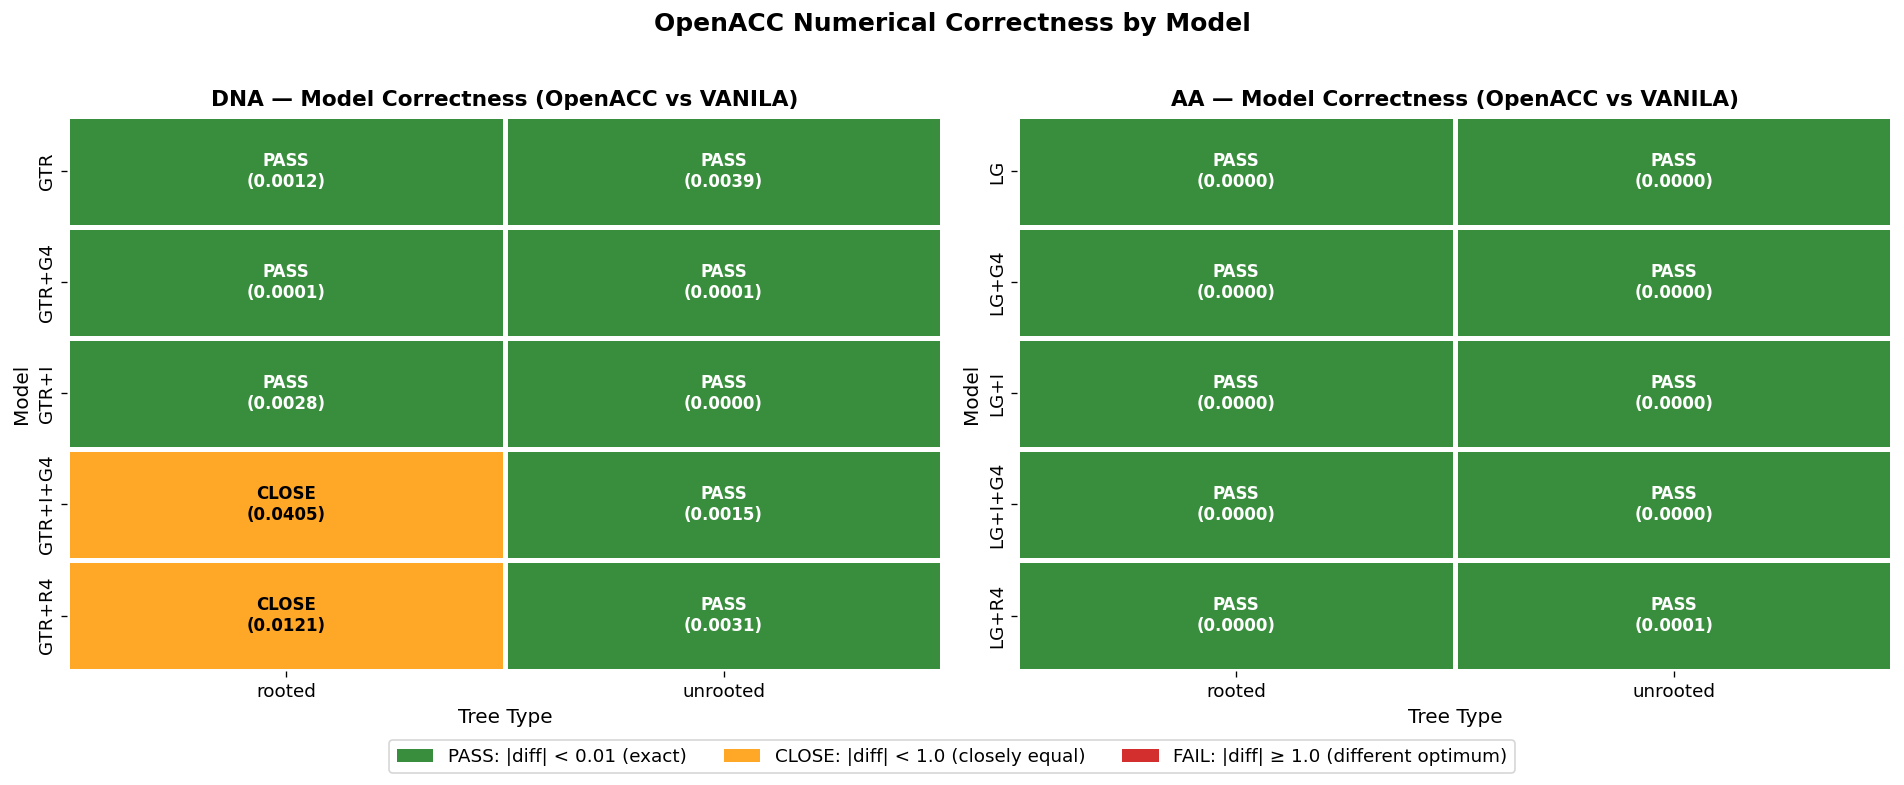

In [16]:
# Visual correctness heatmap with 3-tier coloring
from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 3-tier: 0=FAIL(red), 1=CLOSE(yellow/amber), 2=PASS(green)
cmap_3tier = ListedColormap(['#d32f2f', '#ffa726', '#388e3c'])

for i, (dt, label) in enumerate([('DNA', 'DNA'), ('AA', 'AA')]):
    ax = axes[i]
    subset = correctness_df[correctness_df['data_type'] == dt].copy()
    if len(subset) == 0:
        ax.set_title(f'{label} \u2014 No data')
        ax.axis('off')
        continue
    
    def status_to_num(s):
        if '\u2705' in s: return 2
        if '\u2248' in s: return 1
        return 0
    
    subset['status_num'] = subset['STATUS'].apply(status_to_num)
    pivot = subset.pivot_table(index='model', columns='tree_type', values='status_num', fill_value=-1).astype(int)
    
    sns.heatmap(pivot, annot=False, cmap=cmap_3tier, vmin=0, vmax=2,
                ax=ax, linewidths=2, cbar=False,
                xticklabels=True, yticklabels=True)
    
    for y_idx, model in enumerate(pivot.index):
        for x_idx, tt in enumerate(pivot.columns):
            val = pivot.loc[model, tt]
            if val == 2:
                text = 'PASS'
                color = 'white'
            elif val == 1:
                text = 'CLOSE'
                color = 'black'
            else:
                text = 'FAIL'
                color = 'white'
            
            # Add max diff below label
            row = subset[(subset['model'] == model) & (subset['tree_type'] == tt)]
            if len(row) > 0:
                max_d = row.iloc[0]['max |LL diff|']
                text += f'\n({max_d:.4f})'
            
            ax.text(x_idx + 0.5, y_idx + 0.5, text, ha='center', va='center', 
                    fontsize=10, fontweight='bold', color=color)
    
    ax.set_title(f'{label} \u2014 Model Correctness (OpenACC vs VANILA)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Tree Type', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#388e3c', label='PASS: |diff| < 0.01 (exact)'),
    Patch(facecolor='#ffa726', label='CLOSE: |diff| < 1.0 (closely equal)'),
    Patch(facecolor='#d32f2f', label='FAIL: |diff| \u2265 1.0 (different optimum)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=11, 
           bbox_to_anchor=(0.5, -0.05), frameon=True)

plt.suptitle('OpenACC Numerical Correctness by Model', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{cwd}/correctness_matrix.png', bbox_inches='tight')
plt.show()

# 9. Scatter: VANILA LL vs OpenACC LL

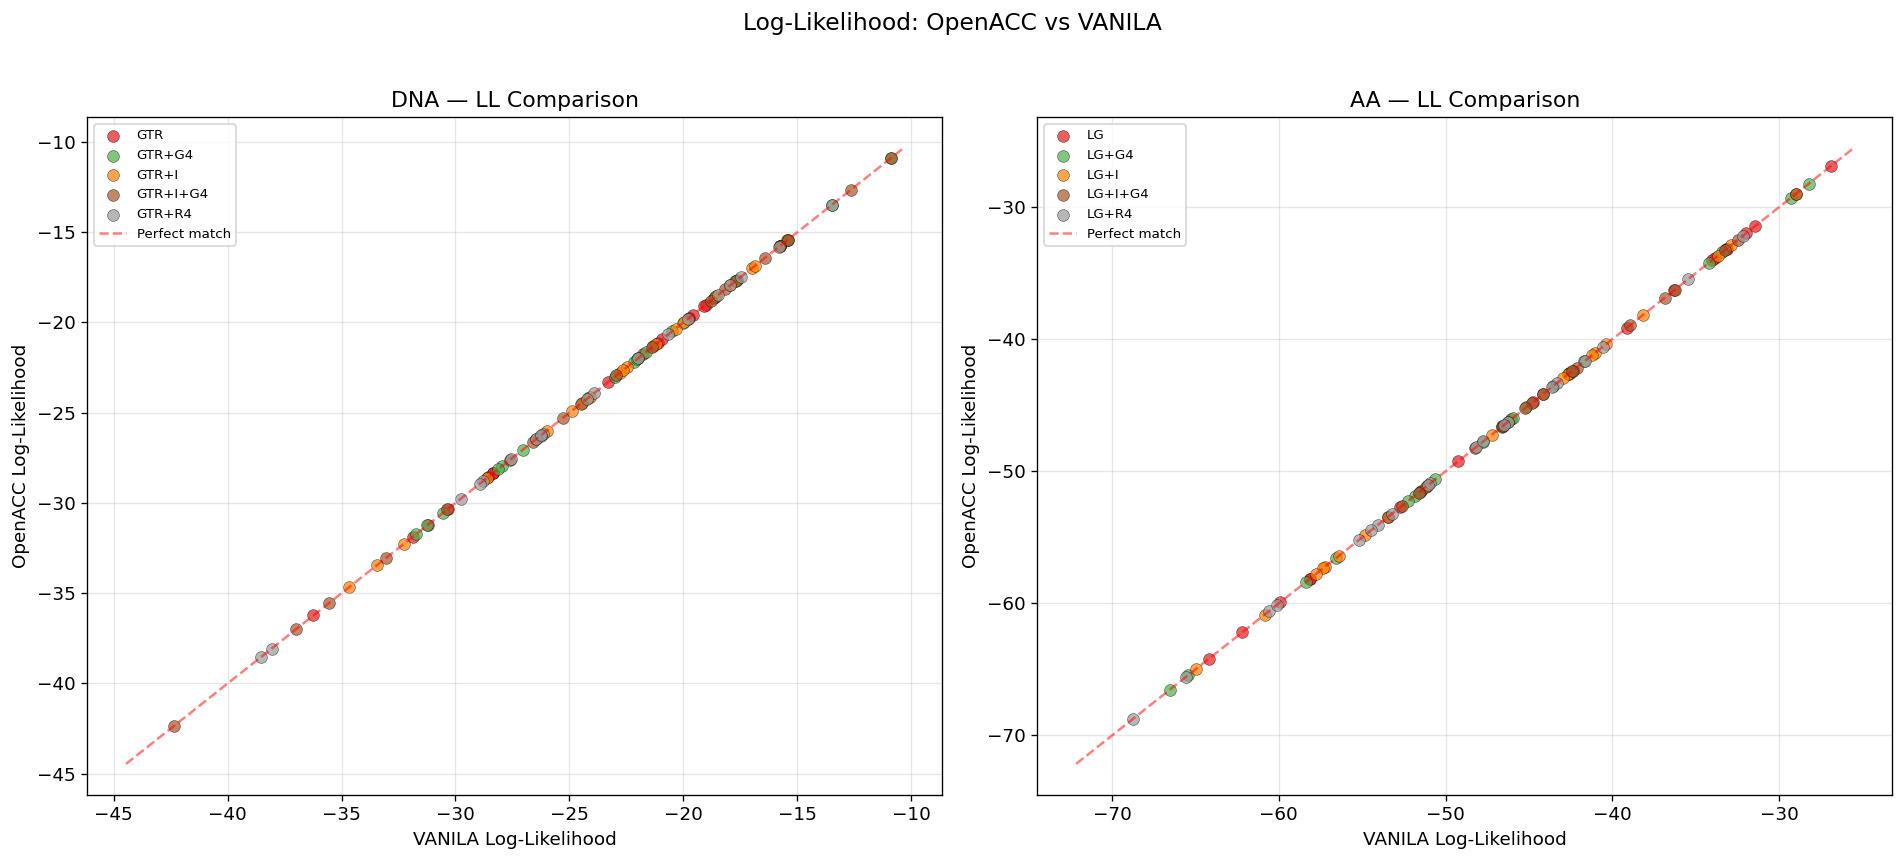

In [17]:
# Scatter plot: VANILA LL vs OPENACC LL, colored by model
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, dt in enumerate(['DNA', 'AA']):
    ax = axes[i]
    subset = both[both['data_type'] == dt]
    if len(subset) == 0:
        ax.set_title(f'{dt} \u2014 No data')
        continue
    
    models = sorted(subset['model'].unique())
    colors = plt.cm.Set1(np.linspace(0, 1, len(models)))
    
    for model, color in zip(models, colors):
        msub = subset[subset['model'] == model]
        ax.scatter(msub['final_ll_vanila'], msub['final_ll_openacc'], 
                   label=model, alpha=0.7, s=50, color=color, edgecolors='black', linewidth=0.3)
    
    all_lls = pd.concat([subset['final_ll_vanila'], subset['final_ll_openacc']])
    lim_min, lim_max = all_lls.min() * 1.05, all_lls.max() * 0.95
    ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', alpha=0.5, label='Perfect match')
    
    ax.set_xlabel('VANILA Log-Likelihood')
    ax.set_ylabel('OpenACC Log-Likelihood')
    ax.set_title(f'{dt} \u2014 LL Comparison')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Log-Likelihood: OpenACC vs VANILA', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{cwd}/ll_scatter.png', bbox_inches='tight')
plt.show()

# 10. Optimization Rounds Comparison

In [18]:
# Compare number of optimization rounds
print("=" * 90)
print("OPTIMIZATION ROUNDS: OpenACC vs VANILA")
print("=" * 90)

both['rounds_diff'] = both['opt_rounds_openacc'] - both['opt_rounds_vanila']

rounds_summary = both.groupby(['data_type', 'tree_type', 'model']).agg(
    mean_rounds_vanila=('opt_rounds_vanila', 'mean'),
    mean_rounds_openacc=('opt_rounds_openacc', 'mean'),
    mean_rounds_diff=('rounds_diff', 'mean'),
    max_rounds_diff=('rounds_diff', lambda x: x.abs().max()),
).round(1)
display(rounds_summary)

OPTIMIZATION ROUNDS: OpenACC vs VANILA


mean_rounds_vanila  mean_rounds_openacc  \
data_type tree_type model                                               
AA        rooted    LG                       1.0                  1.0   
                    LG+G4                    2.5                  2.5   
                    LG+I                     2.5                  2.5   
                    LG+I+G4                  NaN                  NaN   
                    LG+R4                    3.1                  3.1   
          unrooted  LG                       1.0                  1.0   
                    LG+G4                    2.6                  2.6   
                    LG+I                     2.1                  2.1   
                    LG+I+G4                  NaN                  NaN   
                    LG+R4                    4.4                  4.4   
DNA       rooted    GTR                      5.0                  5.0   
                    GTR+G4                   6.3                  6.3   
                    GTR+I                    8.5                  8.5   
                    GTR+I+G4                 NaN                  NaN   
                    GTR+R4                   5.4                  5.5   
          unrooted  GTR                      5.1                  5.1   
                    GTR+G4                   4.5                  4.5   
                    GTR+I                    4.7                  4.7   
                    GTR+I+G4                 NaN                  NaN   
                    GTR+R4                   5.9                  6.0   

                              mean_rounds_diff  max_rounds_diff  
data_type tree_type model                                        
AA        rooted    LG                     0.0              0.0  
                    LG+G4                  0.0              0.0  
                    LG+I                   0.0              0.0  
                    LG+I+G4                NaN              NaN  
                    LG+R4                  0.0              0.0  
          unrooted  LG                     0.0              0.0  
                    LG+G4                  0.0              0.0  
                    LG+I                   0.0              0.0  
                    LG+I+G4                NaN              NaN  
                    LG+R4                  0.0              0.0  
DNA       rooted    GTR                    0.0              0.0  
                    GTR+G4                 0.0              0.0  
                    GTR+I                  0.0              0.0  
                    GTR+I+G4               NaN              NaN  
                    GTR+R4                 0.1              1.0  
          unrooted  GTR                    0.0              0.0  
                    GTR+G4                 0.0              0.0  
                    GTR+I                  0.0              0.0  
                    GTR+I+G4               NaN              NaN  
                    GTR+R4                 0.1              1.0

# 11. LG+C60 Special Analysis (Mixture Model)

In [19]:
# Check LG+C60 results specifically
c60 = df[df['model'] == 'LG+C60'].copy()
if len(c60) > 0:
    print(f"LG+C60 records: {len(c60)}")
    print(f"\nBreakdown:")
    display(c60.groupby(['tree_type', 'backend']).agg(
        n=('final_ll', 'count'),
        mean_ll=('final_ll', 'mean'),
        mean_opt=('opt_time', 'mean'),
        n_underflow=('has_underflow', 'sum'),
    ).round(4))
    
    c60_both = c60.pivot_table(index=['tree_type', 'tree_num'], columns='backend', 
                                values='final_ll')
    if 'VANILA' in c60_both.columns and 'OPENACC' in c60_both.columns:
        c60_both['diff'] = c60_both['OPENACC'] - c60_both['VANILA']
        print(f"\nLL differences (C60):")
        display(c60_both)
else:
    print("No LG+C60 results found.")

No LG+C60 results found.


# 12. Detailed Failure Analysis

Per-tree breakdown of every failing model, showing which trees fail and why.

In [20]:
# Detailed per-tree analysis of non-PASS models (CLOSE + FAIL)
nonpass_cases = correctness_df[~correctness_df['STATUS'].str.contains('PASS')]

if len(nonpass_cases) == 0:
    print("\u2705 All models PASS — no failures to analyze!")
else:
    for _, frow in nonpass_cases.iterrows():
        dt, tt, model = frow['data_type'], frow['tree_type'], frow['model']
        sub = both[(both['data_type'] == dt) & (both['tree_type'] == tt) & (both['model'] == model)].copy()
        sub = sub.sort_values('tree_num')
        
        print(f"\n{'='*100}")
        print(f"{frow['STATUS']}  {dt} / {tt} / {model}  \u2014  {int(frow['n_ll_exact (<0.01)'])}/{int(frow['n_trees'])} exact match")
        print(f"{'='*100}")
        print(f"{'Tree':>6} | {'VANILA LL':>18} | {'OpenACC LL':>18} | {'LL diff':>12} | {'|diff|':>10} | {'Match':>5}")
        print(f"{'-'*6}-+-{'-'*18}-+-{'-'*18}-+-{'-'*12}-+-{'-'*10}-+-{'-'*5}")
        
        for _, row in sub.iterrows():
            v_ll = row['final_ll_vanila']
            o_ll = row['final_ll_openacc']
            diff = o_ll - v_ll
            absd = abs(diff)
            match = "\u2705" if absd < 0.01 else "\u2248" if absd < 1.0 else "\u274c"
            print(f"{int(row['tree_num']):>6} | {v_ll:>18.4f} | {o_ll:>18.4f} | {diff:>+12.4f} | {absd:>10.4f} | {match:>5}")
        
        gpu_better = (sub['ll_diff'] > 0.01).sum()
        gpu_worse = (sub['ll_diff'] < -0.01).sum()
        print(f"\nGPU finds higher LL: {gpu_better}/10,  GPU finds lower LL: {gpu_worse}/10")


≈ CLOSE  DNA / rooted / GTR+I+G4  —  9/10 exact match
  Tree |          VANILA LL |         OpenACC LL |      LL diff |     |diff| | Match
-------+--------------------+--------------------+--------------+------------+------
     1 |           -26.6021 |           -26.6019 |      +0.0002 |     0.0002 |     ✅
     2 |           -42.3377 |           -42.3377 |      +0.0000 |     0.0000 |     ✅
     3 |           -15.4437 |           -15.4437 |      +0.0000 |     0.0000 |     ✅
     4 |           -18.8078 |           -18.8078 |      +0.0000 |     0.0000 |     ✅
     5 |           -16.4382 |           -16.4382 |      +0.0000 |     0.0000 |     ✅
     6 |           -22.9466 |           -22.9061 |      +0.0405 |     0.0405 |     ≈
     7 |           -15.4134 |           -15.4134 |      +0.0000 |     0.0000 |     ✅
     8 |           -30.3507 |           -30.3469 |      +0.0038 |     0.0038 |     ✅
     9 |           -10.8890 |           -10.8890 |      +0.0000 |     0.0000 |     ✅
    10 |  

### FreeRate (+R4) Parameter Comparison: Worst Failures

Comparing the site rate categories found by CPU vs GPU for the worst-failing trees.

In [21]:
# Parse FreeRate parameters for worst R4 trees (even if passing)
import os, re

freerate_pattern2 = re.compile(r'Site proportion and rates:\s+(.+)')
gamma_pattern2 = re.compile(r'Gamma shape alpha:\s+([\d.]+)')
pinvar_pattern2 = re.compile(r'Proportion of invariable sites:\s+([\d.]+)')
ll_file_pattern2 = re.compile(r'Log-likelihood of the tree:\s+([-\d.]+)')

# Show worst tree per non-PASS model
nonpass_for_params = correctness_df[~correctness_df['STATUS'].str.contains('PASS')]
if len(nonpass_for_params) == 0:
    # If all pass, show R4 models anyway for reference
    nonpass_for_params = correctness_df[correctness_df['model'].str.contains('R4|I\+G4')].sort_values('max |LL diff|', ascending=False).head(4)

for _, frow in nonpass_for_params.iterrows():
    dt, tt, model = frow['data_type'], frow['tree_type'], frow['model']
    sub = both[(both['data_type'] == dt) & (both['tree_type'] == tt) & (both['model'] == model)]
    worst = sub.loc[sub['ll_abs_diff'].idxmax()]
    tree_num = int(worst['tree_num'])
    
    tree_dir = os.path.join(results_path, dt, tt, model, f'tree_{tree_num}')
    
    print(f"\n{'='*100}")
    print(f"{dt} / {tt} / {model} / tree_{tree_num}  (largest diff, |diff| = {worst['ll_abs_diff']:.4f})")
    print(f"{'='*100}")
    
    for backend in ['VANILA', 'OPENACC']:
        iqtree_files = [f for f in os.listdir(tree_dir) if f.endswith('.iqtree') and backend in f]
        if not iqtree_files:
            continue
        
        with open(os.path.join(tree_dir, iqtree_files[0])) as f:
            content = f.read()
        
        ll = ll_file_pattern2.search(content)
        ll_val = float(ll.group(1)) if ll else None
        
        rates = freerate_pattern2.search(content)
        rates_str = rates.group(1).strip() if rates else None
        
        gamma = gamma_pattern2.search(content)
        gamma_val = gamma.group(1) if gamma else None
        
        pinvar = pinvar_pattern2.search(content)
        pinvar_val = pinvar.group(1) if pinvar else None
        
        print(f"\n  {backend}:")
        print(f"    Log-likelihood: {ll_val}")
        if rates_str:
            print(f"    Site rates:     {rates_str}")
            pairs = re.findall(r'\(([^)]+)\)', rates_str)
            rates_vals = []
            for pair in pairs:
                parts = pair.split(',')
                if len(parts) == 2:
                    try:
                        rates_vals.append(float(parts[1]))
                    except: pass
            if rates_vals and min(rates_vals) > 0:
                rate_range = max(rates_vals) / min(rates_vals)
                print(f"    Rate range:     {min(rates_vals):.4f} \u2013 {max(rates_vals):.4f} (ratio: {rate_range:.1f}x)")
        if gamma_val:
            print(f"    Gamma alpha:    {gamma_val}")
        if pinvar_val:
            print(f"    Prop invariant: {pinvar_val}")


DNA / rooted / GTR+I+G4 / tree_6  (largest diff, |diff| = 0.0405)

  VANILA:
    Log-likelihood: -22.9466
    Gamma alpha:    998.4
    Prop invariant: 0.07589

  OPENACC:
    Log-likelihood: -22.9061
    Gamma alpha:    998.4
    Prop invariant: 0.07769

DNA / rooted / GTR+R4 / tree_9  (largest diff, |diff| = 0.0121)

  VANILA:
    Log-likelihood: -29.7766
    Site rates:     (0.2708,0.9997) (0.2385,0.9998) (0.1989,1) (0.2917,1)
    Rate range:     0.9997 – 1.0000 (ratio: 1.0x)

  OPENACC:
    Log-likelihood: -29.7645
    Site rates:     (0.1989,0.9997) (0.2708,0.9999) (0.2385,0.9999) (0.2917,1)
    Rate range:     0.9997 – 1.0000 (ratio: 1.0x)


### Per-Tree Log-Likelihood Difference for Failing Models

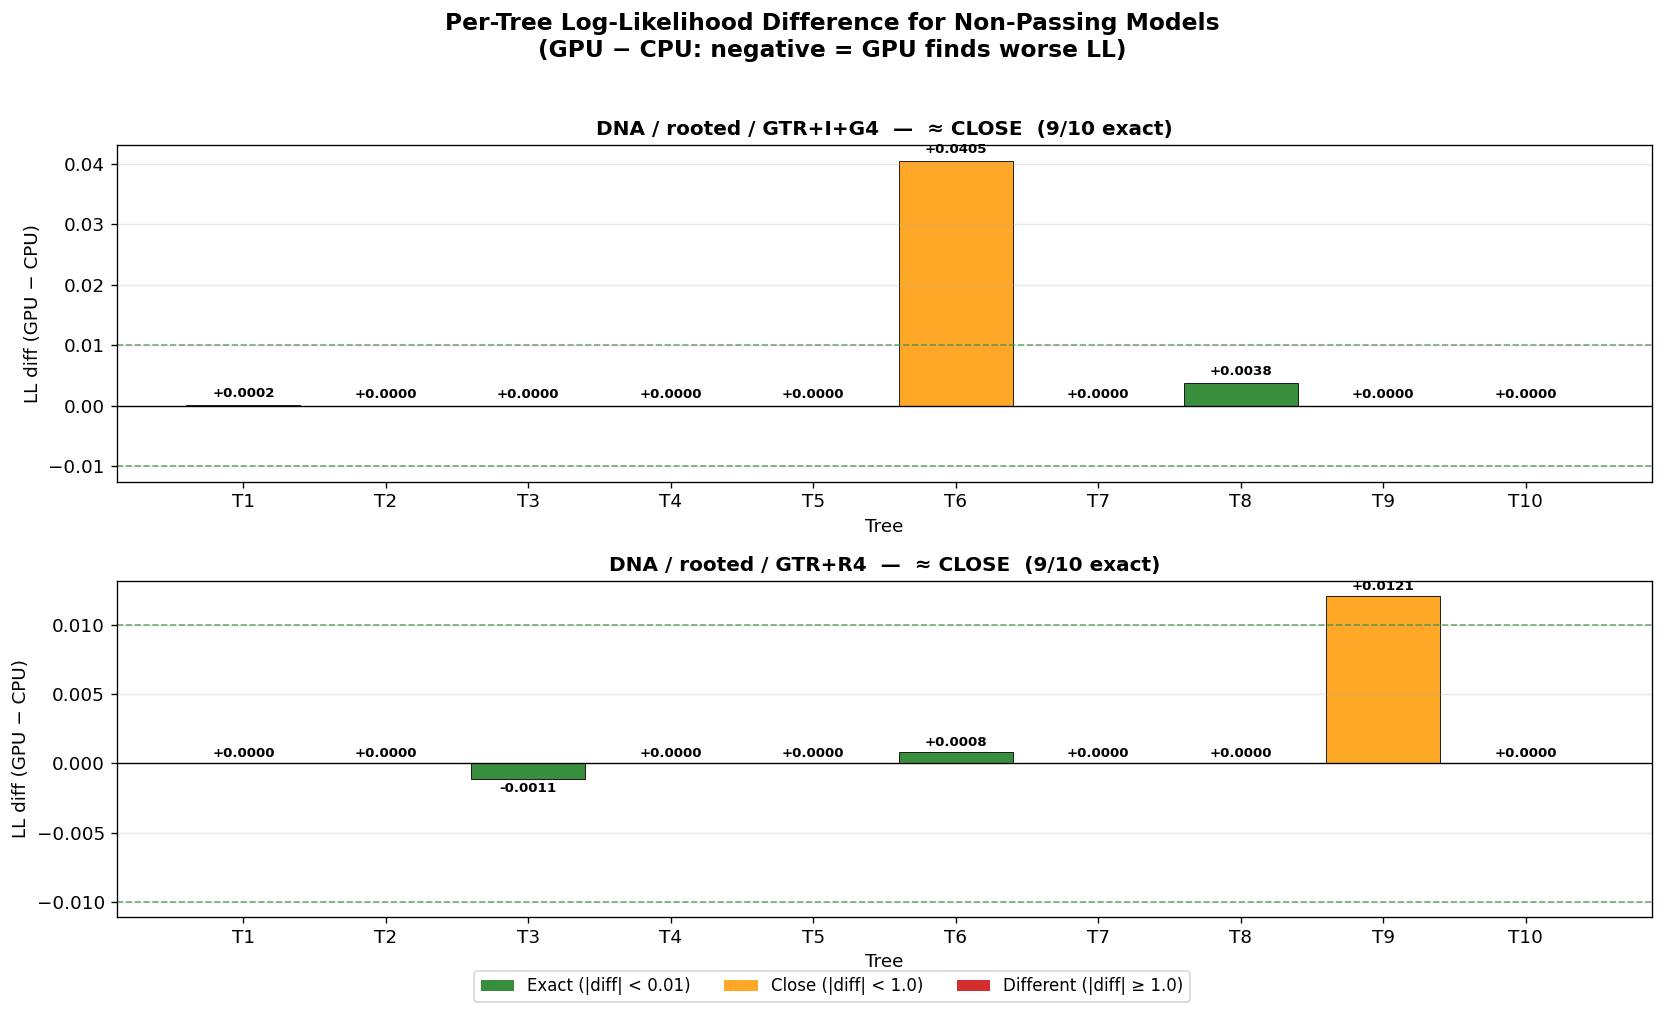

Saved per_tree_ll_diff_failing.png


In [22]:
# Per-tree LL diff bar chart for each non-PASS model (CLOSE + FAIL)
nonpass_models = correctness_df[~correctness_df['STATUS'].str.contains('PASS')]

n_nonpass = len(nonpass_models)
if n_nonpass == 0:
    print("All models PASS — no failure chart needed.")
else:
    fig, axes = plt.subplots(n_nonpass, 1, figsize=(14, 4 * n_nonpass))
    if n_nonpass == 1:
        axes = [axes]

    for idx, (_, frow) in enumerate(nonpass_models.iterrows()):
        ax = axes[idx]
        dt, tt, model = frow['data_type'], frow['tree_type'], frow['model']
        sub = both[(both['data_type'] == dt) & (both['tree_type'] == tt) & (both['model'] == model)].copy()
        sub = sub.sort_values('tree_num')
        
        trees = sub['tree_num'].astype(int).values
        diffs = sub['ll_diff'].values
        abs_diffs = sub['ll_abs_diff'].values
        
        bar_colors = []
        for d in abs_diffs:
            if d < 0.01:
                bar_colors.append('#388e3c')
            elif d < 1.0:
                bar_colors.append('#ffa726')
            else:
                bar_colors.append('#d32f2f')
        
        bars = ax.bar([f'T{t}' for t in trees], diffs, color=bar_colors, edgecolor='black', linewidth=0.5)
        
        for bar, d, ad in zip(bars, diffs, abs_diffs):
            va = 'bottom' if d >= 0 else 'top'
            y_pos = d + (0.02 * max(abs_diffs)) if d >= 0 else d - (0.02 * max(abs_diffs))
            ax.text(bar.get_x() + bar.get_width()/2, y_pos, f'{d:+.4f}', 
                    ha='center', va=va, fontsize=8, fontweight='bold')
        
        ax.axhline(y=0, color='black', linewidth=0.8)
        ax.axhline(y=0.01, color='#388e3c', linewidth=1, linestyle='--', alpha=0.7)
        ax.axhline(y=-0.01, color='#388e3c', linewidth=1, linestyle='--', alpha=0.7)
        
        max_abs = max(abs_diffs) if len(abs_diffs) > 0 else 1
        if max_abs > 0.5:
            ax.axhline(y=1.0, color='#d32f2f', linewidth=1, linestyle='--', alpha=0.5)
            ax.axhline(y=-1.0, color='#d32f2f', linewidth=1, linestyle='--', alpha=0.5)
        
        status = frow['STATUS']
        n_exact = int(frow['n_ll_exact (<0.01)'])
        ax.set_title(f'{dt} / {tt} / {model}  \u2014  {status}  ({n_exact}/10 exact)', 
                     fontsize=12, fontweight='bold')
        ax.set_ylabel('LL diff (GPU \u2212 CPU)', fontsize=11)
        ax.set_xlabel('Tree', fontsize=11)
        ax.grid(axis='y', alpha=0.3)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#388e3c', label='Exact (|diff| < 0.01)'),
        Patch(facecolor='#ffa726', label='Close (|diff| < 1.0)'),
        Patch(facecolor='#d32f2f', label='Different (|diff| \u2265 1.0)'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=10, 
               bbox_to_anchor=(0.5, -0.02), frameon=True)

    plt.suptitle('Per-Tree Log-Likelihood Difference for Non-Passing Models\n(GPU \u2212 CPU: negative = GPU finds worse LL)',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{cwd}/per_tree_ll_diff_failing.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved per_tree_ll_diff_failing.png')

### FreeRate Rate Category Comparison (CPU vs GPU)

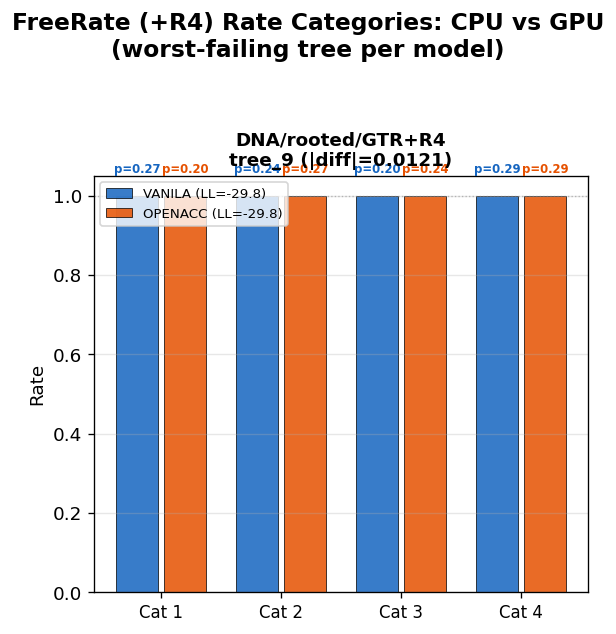

Saved freerate_comparison.png


In [23]:
# Visual comparison of FreeRate rate categories for worst trees (any non-PASS R4)
import os

freerate_pattern = re.compile(r'Site proportion and rates:\s+(.+)')
ll_file_pattern = re.compile(r'Log-likelihood of the tree:\s+([-\d.]+)')

# Find R4 models that are NOT fully PASS
r4_nonpass = correctness_df[(~correctness_df['STATUS'].str.contains('PASS')) & 
                             (correctness_df['model'].str.contains('R4'))]

# If all R4 pass, show the ones with largest diff anyway for comparison
if len(r4_nonpass) == 0:
    r4_all = correctness_df[correctness_df['model'].str.contains('R4')].copy()
    r4_all = r4_all.sort_values('max |LL diff|', ascending=False)
    r4_show = r4_all.head(min(4, len(r4_all)))
    title_suffix = '(all R4 models pass — showing largest diffs)'
else:
    r4_show = r4_nonpass
    title_suffix = '(worst-failing tree per model)'

n_r4 = len(r4_show)
if n_r4 == 0:
    print("No R4 models found.")
else:
    fig, axes = plt.subplots(1, n_r4, figsize=(5 * n_r4, 5))
    if n_r4 == 1:
        axes = [axes]
    
    for idx, (_, frow) in enumerate(r4_show.iterrows()):
        ax = axes[idx]
        dt, tt, model = frow['data_type'], frow['tree_type'], frow['model']
        sub = both[(both['data_type'] == dt) & (both['tree_type'] == tt) & (both['model'] == model)]
        worst = sub.loc[sub['ll_abs_diff'].idxmax()]
        tree_num = int(worst['tree_num'])
        tree_dir = os.path.join(results_path, dt, tt, model, f'tree_{tree_num}')
        
        for backend, color, offset in [('VANILA', '#1565C0', -0.2), ('OPENACC', '#E65100', 0.2)]:
            iqtree_files = [f for f in os.listdir(tree_dir) if f.endswith('.iqtree') and backend in f]
            if not iqtree_files:
                continue
            with open(os.path.join(tree_dir, iqtree_files[0])) as f:
                content = f.read()
            
            ll_m = ll_file_pattern.search(content)
            ll_val = float(ll_m.group(1)) if ll_m else None
            
            rates_m = freerate_pattern.search(content)
            if rates_m:
                pairs = re.findall(r'\(([^)]+)\)', rates_m.group(1))
                props, rates = [], []
                for pair in pairs:
                    parts = pair.split(',')
                    if len(parts) == 2:
                        props.append(float(parts[0]))
                        rates.append(float(parts[1]))
                
                x = np.arange(len(rates))
                label = f'{backend} (LL={ll_val:.1f})'
                ax.bar(x + offset, rates, 0.35, label=label, color=color, alpha=0.85, 
                       edgecolor='black', linewidth=0.5)
                
                for xi, (p, r) in enumerate(zip(props, rates)):
                    va = 'bottom' if r >= 0 else 'top'
                    ax.text(xi + offset, r + 0.05, f'p={p:.2f}', ha='center', va=va, 
                            fontsize=7, color=color, fontweight='bold')
        
        ax.set_xticks(np.arange(4))
        ax.set_xticklabels([f'Cat {i+1}' for i in range(4)], fontsize=10)
        ax.set_ylabel('Rate', fontsize=11)
        ax.set_title(f'{dt}/{tt}/{model}\ntree_{tree_num} (|diff|={worst["ll_abs_diff"]:.4f})', 
                     fontsize=11, fontweight='bold')
        ax.legend(fontsize=8, loc='upper left')
        ax.grid(axis='y', alpha=0.3)
        ax.axhline(y=1.0, color='gray', linewidth=0.8, linestyle=':', alpha=0.5)
    
    plt.suptitle(f'FreeRate (+R4) Rate Categories: CPU vs GPU\n{title_suffix}',
                 fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.savefig(f'{cwd}/freerate_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved freerate_comparison.png')

### Optimization Rounds: CPU vs GPU for Failing Models

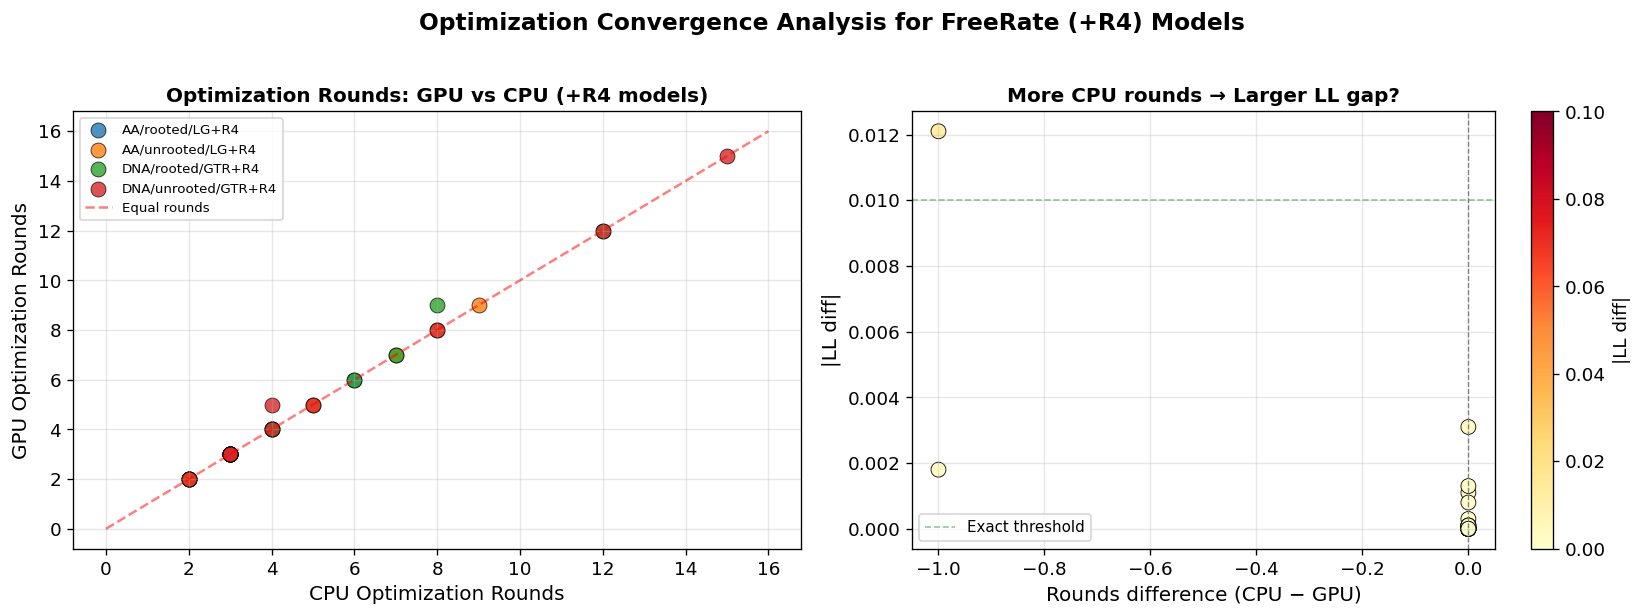

Saved r4_optimization_analysis.png


In [24]:
# Scatter: opt rounds VANILA vs OPENACC for R4 models
r4_both = both[both['model'].str.contains('R4')].copy()

if len(r4_both) > 0 and r4_both['opt_rounds_vanila'].notna().any():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: rounds comparison scatter
    ax = axes[0]
    for (dt, tt, model), group in r4_both.groupby(['data_type', 'tree_type', 'model']):
        label = f'{dt}/{tt}/{model}'
        v_rounds = group['opt_rounds_vanila'].dropna()
        o_rounds = group['opt_rounds_openacc'].dropna()
        if len(v_rounds) > 0 and len(o_rounds) > 0:
            ax.scatter(group['opt_rounds_vanila'], group['opt_rounds_openacc'], 
                       label=label, s=80, alpha=0.8, edgecolors='black', linewidth=0.5)
    
    all_rounds = pd.concat([r4_both['opt_rounds_vanila'], r4_both['opt_rounds_openacc']]).dropna()
    if len(all_rounds) > 0:
        max_r = all_rounds.max()
        ax.plot([0, max_r+1], [0, max_r+1], 'r--', alpha=0.5, label='Equal rounds')
    ax.set_xlabel('CPU Optimization Rounds', fontsize=12)
    ax.set_ylabel('GPU Optimization Rounds', fontsize=12)
    ax.set_title('Optimization Rounds: GPU vs CPU (+R4 models)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Right: rounds vs |LL diff|
    ax = axes[1]
    valid = r4_both[r4_both['opt_rounds_vanila'].notna() & r4_both['opt_rounds_openacc'].notna()]
    if len(valid) > 0:
        rounds_diff = valid['opt_rounds_vanila'] - valid['opt_rounds_openacc']
        max_d = valid['ll_abs_diff'].max()
        sc = ax.scatter(rounds_diff, valid['ll_abs_diff'], 
                        c=valid['ll_abs_diff'], cmap='YlOrRd', s=80, 
                        edgecolors='black', linewidth=0.5, vmin=0, vmax=max(max_d, 0.1))
        ax.set_xlabel('Rounds difference (CPU \u2212 GPU)', fontsize=12)
        ax.set_ylabel('|LL diff|', fontsize=12)
        ax.set_title('More CPU rounds \u2192 Larger LL gap?', fontsize=12, fontweight='bold')
        ax.axvline(x=0, color='gray', linewidth=0.8, linestyle='--')
        ax.axhline(y=0.01, color='#388e3c', linewidth=1, linestyle='--', alpha=0.5, label='Exact threshold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.colorbar(sc, ax=ax, label='|LL diff|')
    
    plt.suptitle('Optimization Convergence Analysis for FreeRate (+R4) Models',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{cwd}/r4_optimization_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved r4_optimization_analysis.png')
else:
    print("No R4 model data with optimization rounds available.")

# 12. Final Summary Table

In [25]:
print("=" * 90)
print("FINAL SUMMARY: OpenACC Correctness for Complex Models (Final)")
print("=" * 90)
print()

all_models = df.groupby(['data_type', 'model', 'backend']).size().unstack(fill_value=0)
print("All models tested (record counts):")
display(all_models)

print("\n" + "-" * 90)
print("CORRECTNESS RESULTS (3-tier):")
print("-" * 90)

n_pass = (correctness_df['STATUS'].str.contains('PASS')).sum()
n_close = (correctness_df['STATUS'].str.contains('CLOSE')).sum()
n_fail = (correctness_df['STATUS'].str.contains('FAIL')).sum()
n_total = len(correctness_df)

print(f"\n  Total model\u00d7tree_type combinations tested: {n_total}")
print(f"  \u2705 PASS  (exact, |diff| < 0.01):            {n_pass}")
print(f"  \u2248 CLOSE (closely equal, |diff| < 1.0):     {n_close}")
print(f"  \u274c FAIL  (different optimum, |diff| \u2265 1.0):  {n_fail}")
print(f"  Pass + Close rate: {100*(n_pass+n_close)/n_total:.1f}%")

if n_fail > 0:
    print(f"\n  FAIL models (|diff| \u2265 1.0):")
    for _, row in correctness_df[correctness_df['STATUS'].str.contains('FAIL')].iterrows():
        print(f"    {row['data_type']}/{row['tree_type']}/{row['model']}: "
              f"max|diff|={row['max |LL diff|']:.4f}, "
              f"exact={int(row['n_ll_exact (<0.01)'])}/{int(row['n_trees'])}, "
              f"close={int(row['n_ll_close (<1.0)'])}/{int(row['n_trees'])}")

if n_close > 0:
    print(f"\n  CLOSE models (0.01 \u2264 |diff| < 1.0):")
    for _, row in correctness_df[correctness_df['STATUS'].str.contains('CLOSE')].iterrows():
        print(f"    {row['data_type']}/{row['tree_type']}/{row['model']}: "
              f"max|diff|={row['max |LL diff|']:.4f}, "
              f"exact={int(row['n_ll_exact (<0.01)'])}/{int(row['n_trees'])}")

print(f"\n  PASS models:")
for _, row in correctness_df[correctness_df['STATUS'].str.contains('PASS')].iterrows():
    print(f"    {row['data_type']}/{row['tree_type']}/{row['model']}: "
          f"max|diff|={row['max |LL diff|']:.6f}")

FINAL SUMMARY: OpenACC Correctness for Complex Models (Final)

All models tested (record counts):


backend             OPENACC  VANILA
data_type model                    
AA        LG             20      20
          LG+G4          20      20
          LG+I           20      20
          LG+I+G4        20      20
          LG+R4          20      20
DNA       GTR            20      20
          GTR+G4         20      20
          GTR+I          20      20
          GTR+I+G4       20      20
          GTR+R4         20      20


------------------------------------------------------------------------------------------
CORRECTNESS RESULTS (3-tier):
------------------------------------------------------------------------------------------

  Total model×tree_type combinations tested: 20
  ✅ PASS  (exact, |diff| < 0.01):            18
  ≈ CLOSE (closely equal, |diff| < 1.0):     2
  ❌ FAIL  (different optimum, |diff| ≥ 1.0):  0
  Pass + Close rate: 100.0%

  CLOSE models (0.01 ≤ |diff| < 1.0):
    DNA/rooted/GTR+I+G4: max|diff|=0.0405, exact=9/10
    DNA/rooted/GTR+R4: max|diff|=0.0121, exact=9/10

  PASS models:
    AA/rooted/LG: max|diff|=0.000000
    AA/rooted/LG+G4: max|diff|=0.000000
    AA/rooted/LG+I: max|diff|=0.000000
    AA/rooted/LG+I+G4: max|diff|=0.000000
    AA/rooted/LG+R4: max|diff|=0.000000
    AA/unrooted/LG: max|diff|=0.000000
    AA/unrooted/LG+G4: max|diff|=0.000000
    AA/unrooted/LG+I: max|diff|=0.000000
    AA/unrooted/LG+I+G4: max|diff|=0.000000
    AA/unrooted/LG+R4: max|diff|=0.000100


In [26]:
# Save correctness dataframe to CSV for reference
correctness_df.to_csv(f'{cwd}/correctness_summary.csv', index=False)
print(f"Saved correctness summary to {cwd}/correctness_summary.csv")

# Save full merged comparison to CSV
both.to_csv(f'{cwd}/ll_comparison.csv', index=False)
print(f"Saved LL comparison to {cwd}/ll_comparison.csv")

Saved correctness summary to /Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_19_complexdatafinal/correctness_summary.csv
Saved LL comparison to /Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_19_complexdatafinal/ll_comparison.csv
